## Imports

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import datetime

from sklearn.preprocessing import LabelEncoder

In [214]:
# Load the dataset
df = pd.read_csv('retail.csv',encoding='latin-1')

## Análise dos dados

In [215]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [216]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01T08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01T08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01T08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01T08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01T08:26,3.39,17850.0,United Kingdom


### Valores nulos

In [217]:
for column in df.columns:
    print(f"Column: {column}")
    print(df[column].isnull().sum())
    print("\n")

Column: InvoiceNo
0


Column: StockCode
0


Column: Description
1454


Column: Quantity
0


Column: InvoiceDate
0


Column: UnitPrice
0


Column: CustomerID
135080


Column: Country
0




In [218]:
primeiroNullCustomerID= df[df['CustomerID'].isnull()].index[10]
print(f" linha com valor nulo na coluna 'CustomerID': {primeiroNullCustomerID}")

df.iloc[primeiroNullCustomerID]

 linha com valor nulo na coluna 'CustomerID': 1452


InvoiceNo                                536544
StockCode                                 21809
Description    CHRISTMAS HANGING TREE WITH BELL
Quantity                                      1
InvoiceDate                    2010-12-01T14:32
UnitPrice                                  2.51
CustomerID                                  NaN
Country                          United Kingdom
Name: 1452, dtype: object

In [219]:
primeiroNullDescription= df[df['Description'].isnull()].index[0]
print(f" linha com valor nulo na coluna 'Description': {primeiroNullDescription}")
df.iloc[primeiroNullDescription]

 linha com valor nulo na coluna 'Description': 622


InvoiceNo                536414
StockCode                 22139
Description                 NaN
Quantity                     56
InvoiceDate    2010-12-01T11:52
UnitPrice                   0.0
CustomerID                  NaN
Country          United Kingdom
Name: 622, dtype: object

### Perceber relacao dos NULL entre Description e CustomerID

In [220]:
counter = ((df["Description"].isnull()) & (df["CustomerID"].isnull())).sum()
print(f"Número de linhas com 'Description' e 'CustomerID' nulos: {counter}")

Número de linhas com 'Description' e 'CustomerID' nulos: 1454


In [221]:
counter = ((df["Description"].isnull())).sum()
print(f"Número de linhas com 'Description' nulos: {counter}")

Número de linhas com 'Description' nulos: 1454


In [222]:
counter = ((df["CustomerID"].isnull())).sum()
print(f"Número de linhas com 'CustomerID' nulos: {counter}")

Número de linhas com 'CustomerID' nulos: 135080


##### Ou seja quando não há descrição não há customer

In [223]:
df['Country'].value_counts()
### Label encode possivel

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [224]:
df["Country"] = df["Country"].replace({
    "EIRE": "Ireland"
})

In [225]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: count, Length: 4223, dtype: int64

### Fill dos null com -1 e Unknown

In [226]:
### Replace inplace CustomerID to integer

df['CustomerID'] = df['CustomerID'].fillna(-1).astype(int)

In [227]:
df['Description'] = df.dropna(inplace=False)['Description'].astype(str)

In [228]:
print(df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)])

## Ou seja temos CXXXX que são cancelamentos o que fazer com eles? O A é o quê

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

             InvoiceDate  UnitPrice  CustomerID         Country  
141     2010-12-01T09:41      27.50       145

In [229]:
## Cancelation frequency
df['CancelationFreq'] = df['InvoiceNo'].str.startswith('C').astype(int)

In [230]:
## Remover cancelamentos
df = df[~df['InvoiceNo'].str.contains('C', na=False)]

In [231]:
print("Negative value in Quantity is:",(df.Quantity<0).sum())
print("Negative value in Price is:",(df.UnitPrice<0).sum())

Negative value in Quantity is: 1336
Negative value in Price is: 2


In [232]:
# ## remover negativos, dependendo do contexto, pode ser interessante manter os negativos, por exemplo, para analisar os cancelamentos, ou para analisar devoluções, etc. Mas para análises de vendas, pode ser interessante remover os negativos.
df = df[~(df.Quantity < 0)]
df = df[~(df.UnitPrice < 0)]

In [233]:


# Removing duplicates
print("Number of duplicates before cleaning:",df.duplicated().sum())
df = df.drop_duplicates(keep="first")


Number of duplicates before cleaning: 5231


In [234]:
## Unit price a 0 pode ser artigos de oferta

In [235]:
def detect_outliers_iqr_plot(df, column, show_outliers=True):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Column: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))

    if show_outliers:
        print(outliers)

    # boxplot
    plt.figure()
    plt.boxplot(df[column],vert=False)
    plt.xscale('log')
    plt.xlabel(f'{column} (log scale)')
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

    return outliers

Column: Quantity
Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower bound: -14.0
Upper bound: 26.0
Number of outliers: 27355
       InvoiceNo StockCode                       Description  Quantity  \
9         536367     84879     ASSORTED COLOUR BIRD ORNAMENT        32   
31        536370     10002       INFLATABLE POLITICAL GLOBE         48   
44        536370     22492           MINI PAINT SET VINTAGE         36   
46        536371     22086   PAPER CHAIN KIT 50'S CHRISTMAS         80   
65        536374     21258        VICTORIAN SEWING BOX LARGE        32   
...          ...       ...                               ...       ...   
541835    581579     23581            JUMBO BAG PAISLEY PARK        40   
541865    581583     20725           LUNCH BAG RED RETROSPOT        40   
541866    581583     85038   6 CHOCOLATE LOVE HEART T-LIGHTS        36   
541867    581584     20832  RED FLOCK LOVE HEART PHOTO FRAME        72   
541868    581584     85038   6 CHOCOLATE LOVE HEART T-LIGHTS        48   

    

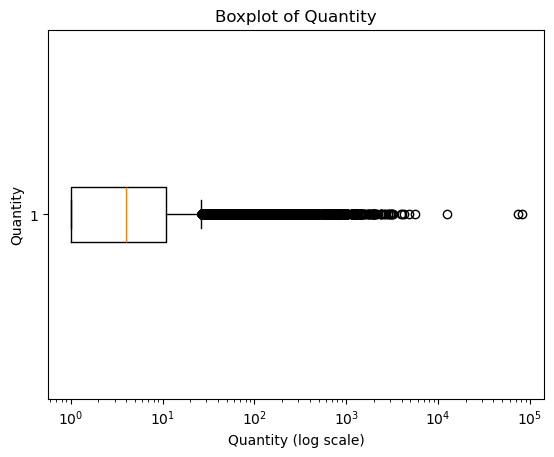

Column: UnitPrice
Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower bound: -3.0700000000000003
Upper bound: 8.45
Number of outliers: 37827
       InvoiceNo StockCode                      Description  Quantity  \
16        536367     22622   BOX OF VINTAGE ALPHABET BLOCKS         2   
45        536370      POST                          POSTAGE         3   
65        536374     21258       VICTORIAN SEWING BOX LARGE        32   
151       536382     22839  3 TIER CAKE TIN GREEN AND CREAM         2   
152       536382     22838    3 TIER CAKE TIN RED AND CREAM         2   
...          ...       ...                              ...       ...   
541768    581578      POST                          POSTAGE         3   
541786    581578     22622   BOX OF VINTAGE ALPHABET BLOCKS         6   
541831    581579     22941     CHRISTMAS LIGHTS 10 REINDEER         4   
541849    581580     22894    TABLECLOTH RED APPLES DESIGN          2   
541892    581586     21217    RED RETROSPOT ROUND CAKE TINS        24   



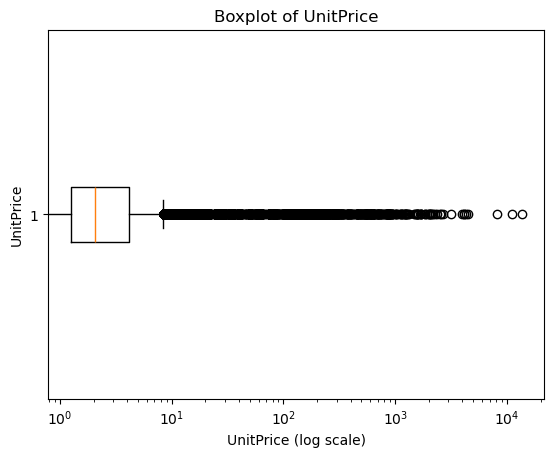

In [236]:
col_list = ["Quantity","UnitPrice"]
for col in col_list:
    detect_outliers_iqr_plot(df, col)

In [237]:
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df.loc[df[column] < lower_limit, column] = lower_limit
    df.loc[df[column] > upper_limit, column] = upper_limit

In [238]:
for col in col_list:
    replace_outliers_iqr(df, col)

Column: Quantity
Q1: 1.0
Q3: 11.0
IQR: 10.0
Lower bound: -14.0
Upper bound: 26.0
Number of outliers: 0
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, CancelationFreq]
Index: []


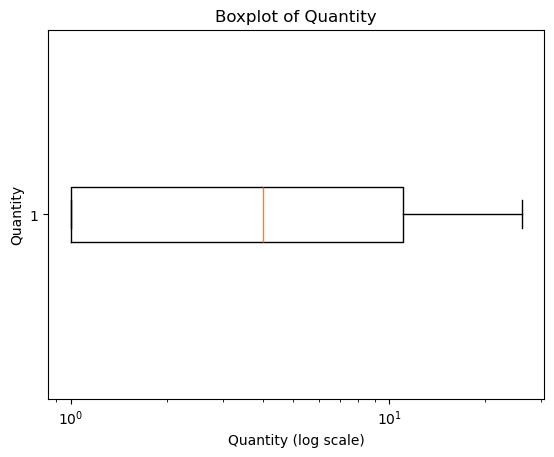

Column: UnitPrice
Q1: 1.25
Q3: 4.13
IQR: 2.88
Lower bound: -3.0700000000000003
Upper bound: 8.45
Number of outliers: 0
Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, CancelationFreq]
Index: []


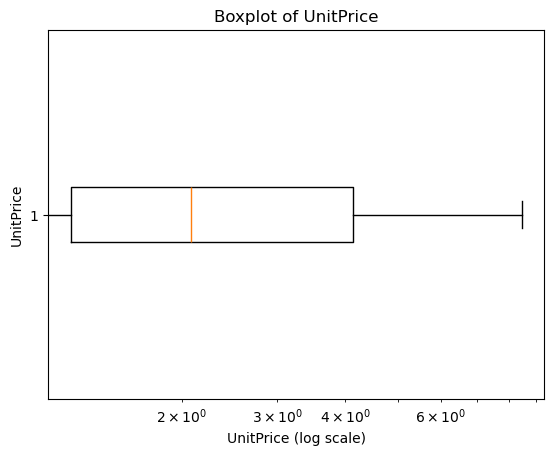

In [239]:
for col in col_list:
    detect_outliers_iqr_plot(df, col)

In [240]:
df.describe()

,Quantity,UnitPrice,CustomerID,CancelationFreq
count,526052.000000,526052.000000,526052.000000,526052.0
mean,6.927363,2.955698,11413.033981,0.0
std,7.573555,2.398585,6813.090290,0.0
min,1.000000,0.000000,-1.000000,0.0
25%,1.000000,1.250000,-1.000000,0.0
50%,4.000000,2.080000,14334.000000,0.0
75%,11.000000,4.130000,16242.000000,0.0
max,26.000000,8.450000,18287.000000,0.0


## 3. Engenharia de Atributos (Feature Engineering)

### 3a. Construção de novas features a partir dos dados transacionais

In [241]:
# Extracting day, month, year, hour, minute, second from InvoiceDate
## Criar novas colunas pq data e hora e muito valioso para analises
## fazemos com cos e sen pq como é ciclico, por exemplo, o dia 1 e o dia 31 tem a mesma relação, ou seja, são próximos, e o mesmo para os meses, etc. Se usarmos apenas o número do dia ou do mês, perdemos essa informação de que eles são próximos. Com sen e cos, conseguimos manter essa informação de proximidade.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day

df['Hour'] = df['InvoiceDate'].dt.hour
df['Minute'] = df['InvoiceDate'].dt.minute

df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek


df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['Minute_sin'] = np.sin(2 * np.pi * df['Minute'] / 60)
df['Minute_cos'] = np.cos(2 * np.pi * df['Minute'] / 60)

## Transform to sin and cos day, the day of week,hours,minute,month
## sin e cons nao se perde info por exemplo em pontos do circulo trig


In [242]:
counter = ((df["Description"].isnull()) & (df["CustomerID"].isnull())).sum()
print(f"Número de linhas com 'Description' e 'CustomerID' nulos: {counter}")

Número de linhas com 'Description' e 'CustomerID' nulos: 0


In [243]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancelationFreq,Year,...,Minute,DayOfWeek,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Hour_sin,Hour_cos,Minute_sin,Minute_cos
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,0,2010,...,26,2,-2.449294e-16,1.0,0.974928,-0.222521,0.866025,-0.5,0.406737,-0.913545
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,2010,...,26,2,-2.449294e-16,1.0,0.974928,-0.222521,0.866025,-0.5,0.406737,-0.913545
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,0,2010,...,26,2,-2.449294e-16,1.0,0.974928,-0.222521,0.866025,-0.5,0.406737,-0.913545
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,2010,...,26,2,-2.449294e-16,1.0,0.974928,-0.222521,0.866025,-0.5,0.406737,-0.913545
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,0,2010,...,26,2,-2.449294e-16,1.0,0.974928,-0.222521,0.866025,-0.5,0.406737,-0.913545


In [244]:
## Considerar apenas hemisferio norte paises europeus

In [245]:
## Dos paises pode se estrair estação do ano
## Pode influenciar sazonalidade de produtos, por exemplo, guarda-chuva no inverno, etc.

def get_season(dt):
    hemisphere = "north"
    dt = dt.date()
    y = dt.year
    
    seasons_north = {
        "spring": (datetime.date(y,3,20), datetime.date(y,6,21)),
        "summer": (datetime.date(y,6,21), datetime.date(y,9,23)),
        "autumn": (datetime.date(y,9,23), datetime.date(y,12,21))
    }

    if hemisphere == "north":
        if seasons_north["spring"][0] <= dt < seasons_north["spring"][1]:
            return "Spring"
        elif seasons_north["summer"][0] <= dt < seasons_north["summer"][1]:
            return "Summer"
        elif seasons_north["autumn"][0] <= dt < seasons_north["autumn"][1]:
            return "Autumn"
        else:
            return "Winter"

In [246]:
df['Season'] = df.apply(lambda row: get_season(row['InvoiceDate']), axis=1)

In [247]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [248]:
Max_date = df["InvoiceDate"].max()
Min_date = df["InvoiceDate"].min()

print("Max date :",Max_date)
print("Min date :",Min_date)

Max date : 2011-12-09 12:50:00
Min date : 2010-12-01 08:26:00


In [249]:
print(df[df["InvoiceDate"].dt.dayofweek == 0])
## diass da semana, 0 é segunda-feira, 1 é terça-feira, etc.

       InvoiceNo StockCode                         Description  Quantity  \
10144     537226     22811            SET OF 6 T-LIGHTS CACTI          6   
10145     537226     21713         CITRONELLA CANDLE FLOWERPOT         8   
10146     537226     22927      GREEN GIANT GARDEN THERMOMETER         2   
10147     537226     20802       SMALL GLASS SUNDAE DISH CLEAR         6   
10148     537226     22052           VINTAGE CARAVAN GIFT WRAP        25   
...          ...       ...                                 ...       ...   
529529    580731     21034        REX CASH+CARRY JUMBO SHOPPER         1   
529530    580732     23079            TOADSTOOL BEDSIDE LIGHT          1   
529531    580732     23108          SET OF 10 LED DOLLY LIGHTS         1   
529532    580732     20972  PINK CREAM FELT CRAFT TRINKET BOX          2   
529533    580732     22969        HOMEMADE JAM SCENTED CANDLES        12   

               InvoiceDate  UnitPrice  CustomerID         Country  \
10144  2010-12-06 

In [250]:
# ── Codificação ordinal da Estação do Ano ──
# Justificação: transformar a variável categórica sazonal em ordinal
# permite capturar a sequência temporal das estações.
season_order = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3}
df['Season_ord'] = df['Season'].map(season_order)

# ── IsWeekend ──
# Justificação: comportamento de compra pode diferir entre semana e fim de semana.
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)


print(df[['Season_ord','IsWeekend',]].head())

   Season_ord  IsWeekend
0           3          0
1           3          0
2           3          0
3           3          0
4           3          0


In [251]:
df[df["StockCode"] == "85123A"].tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancelationFreq,Year,...,DayOfWeek_sin,DayOfWeek_cos,Hour_sin,Hour_cos,Minute_sin,Minute_cos,Season,TotalPrice,Season_ord,IsWeekend
539342,581439,85123A,CREAM HANGING HEART T-LIGHT HOLDER,1,2011-12-08 16:30:00,5.79,-1,United Kingdom,0,2011,...,0.433884,-0.900969,-0.866025,-5.000000e-01,5.665539e-16,-1.000000,Autumn,5.79,3,0
539979,581452,85123A,WHITE HANGING HEART T-LIGHT HOLDER,26,2011-12-08 18:03:00,2.55,17675,United Kingdom,0,2011,...,0.433884,-0.900969,-1.000000,-1.836970e-16,3.090170e-01,0.951057,Autumn,66.30,3,0
540217,581472,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2011-12-08 19:55:00,2.95,15796,United Kingdom,0,2011,...,0.433884,-0.900969,-0.965926,2.588190e-01,-5.000000e-01,0.866025,Autumn,17.70,3,0
540837,581492,85123A,CREAM HANGING HEART T-LIGHT HOLDER,3,2011-12-09 10:03:00,5.79,-1,United Kingdom,0,2011,...,-0.433884,-0.900969,0.500000,-8.660254e-01,3.090170e-01,0.951057,Autumn,17.37,3,0
541639,581538,85123A,CREAM HANGING HEART T-LIGHT HOLDER,1,2011-12-09 11:34:00,2.95,14446,United Kingdom,0,2011,...,-0.433884,-0.900969,0.258819,-9.659258e-01,-4.067366e-01,-0.913545,Autumn,2.95,3,0


In [252]:
# ── InvoiceTotal: valor total por fatura ──
# Justificação: granularidade de invoice é mais relevante do que item individual
# para análises de cesta e comportamento de compra.
invoice_totals = df.groupby('InvoiceNo')['TotalPrice'].sum().reset_index()
invoice_totals.columns = ['InvoiceNo', 'InvoiceTotal']
df = df.merge(invoice_totals, on='InvoiceNo', how='left')

# ── ItemsPerInvoice: nº de linhas (items distintos) por fatura ──
invoice_items = df.groupby('InvoiceNo')['StockCode'].count().reset_index()
invoice_items.columns = ['InvoiceNo', 'ItemsPerInvoice']
df = df.merge(invoice_items, on='InvoiceNo', how='left')

print(df[['InvoiceNo','InvoiceTotal','ItemsPerInvoice']].head())

  InvoiceNo  InvoiceTotal  ItemsPerInvoice
0    536365        139.12                7
1    536365        139.12                7
2    536365        139.12                7
3    536365        139.12                7
4    536365        139.12                7


In [253]:
## Total transactions
df['TotalTransactions'] = df.groupby('CustomerID')['InvoiceNo'].transform('nunique')

## total unique products
df['UniqueProducts'] = df.groupby('CustomerID')['StockCode'].transform('nunique')

## Average transaction value
df['AvgOrderValue'] = df.groupby('InvoiceNo')['TotalPrice'].transform('mean')

In [254]:
## Category - Stock code
df['Category'] = df['StockCode'].astype(str)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'CancelationFreq', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Hour_sin', 'Hour_cos', 'Minute_sin', 'Minute_cos', 'Season', 'TotalPrice', 'Season_ord', 'IsWeekend', 'InvoiceTotal', 'ItemsPerInvoice', 'TotalTransactions', 'UniqueProducts', 'AvgOrderValue', 'Category']


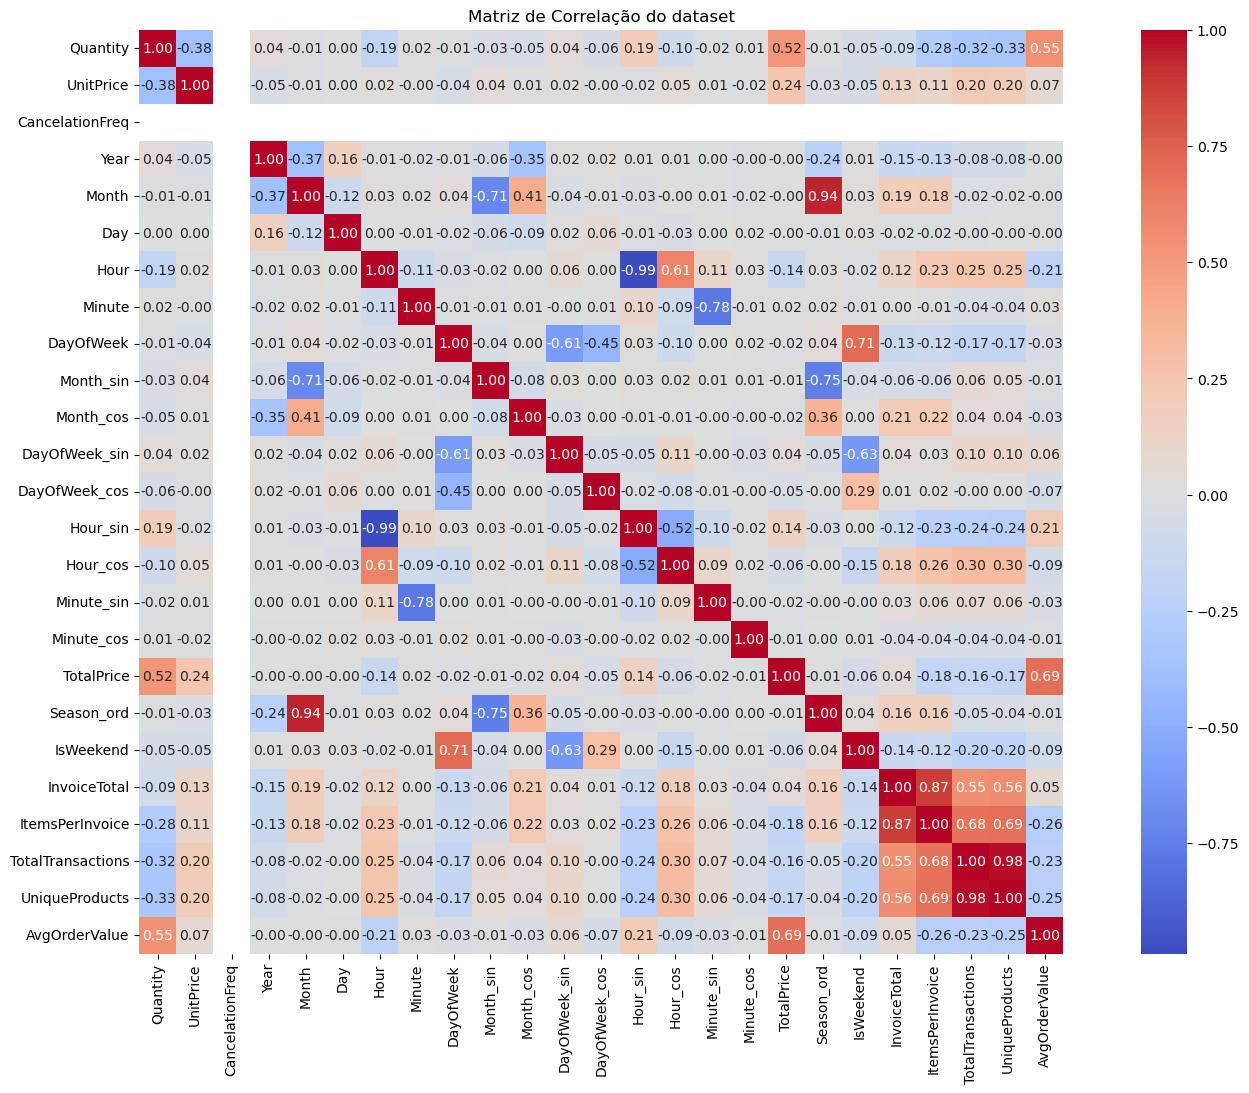

In [255]:
## Confusion matrix
columns = df.columns.tolist()
print(columns)
remove_cols = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID','Country','Season','Category']
columns = [col for col in columns if col not in remove_cols]

plt.figure(figsize=(20, 12))
sns.heatmap(df[columns].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlação do dataset')
plt.show()

### 3b. Abordagem baseada no cliente — Customer Experience Analysis (CXA)

In [256]:
# ── CXA: agregações ao nível do cliente ──
# Justificação: a análise CXA foca-se na experiência e padrão de comportamento
# de cada cliente individual, agregando métricas relevantes por CustomerID.
# Excluímos CustomerID == -1 (transações sem cliente identificado).

df_cust = df[df['CustomerID'] != -1].copy()

snapshot_date = df_cust['InvoiceDate'].max() + pd.Timedelta(days=1)

cxa = df_cust.groupby('CustomerID').agg(
    # Recência: dias desde a última compra
    Recency        = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    # Frequência: nº de faturas distintas
    Frequency      = ('InvoiceNo', 'nunique'),
    # Monetário: valor total gasto
    Monetary       = ('TotalPrice', 'sum'),
    # Ticket médio por fatura
    AvgOrderValue  = ('InvoiceTotal', 'mean'),
    # Média de itens distintos por fatura
    AvgItemsPerOrder = ('ItemsPerInvoice', 'mean'),
    # País principal
    Country        = ('Country', lambda x: x.mode()[0]),
    # Estação mais frequente
    FavSeason      = ('Season', lambda x: x.mode()[0]),
    # Categoria mais comprada
    FavCategory    = ('Category', lambda x: x.mode()[0]),
    # Hora média de compra
    AvgHour        = ('Hour', 'mean'),
    # Meses activos (nº de meses com pelo menos uma compra)
    ActiveMonths   = ('Month', 'nunique'),
).reset_index()

# ── DaysBetweenPurchases: tempo médio entre compras consecutivas ──
def avg_days_between(dates):
    sorted_dates = sorted(dates.unique())
    if len(sorted_dates) < 2:
        return np.nan
    deltas = [(sorted_dates[i+1] - sorted_dates[i]).days for i in range(len(sorted_dates)-1)]
    return np.mean(deltas)

purchase_dates = df_cust.groupby(['CustomerID', 'InvoiceNo'])['InvoiceDate'].min().reset_index()
gap_df = purchase_dates.groupby('CustomerID')['InvoiceDate'].apply(avg_days_between).reset_index()
gap_df.columns = ['CustomerID', 'AvgDaysBetweenPurchases']

cxa = cxa.merge(gap_df, on='CustomerID', how='left')

print(f"CXA dataframe: {cxa.shape}")
print(cxa.describe())

CXA dataframe: (4339, 12)
         CustomerID      Recency    Frequency       Monetary  AvgOrderValue  \
count   4339.000000  4339.000000  4339.000000    4339.000000    4339.000000   
mean   15299.936852    92.518322     4.271952    1381.603852     351.935818   
std     1721.889758   100.009747     7.705493    3506.592236     335.655150   
min    12346.000000     1.000000     1.000000       0.000000       0.000000   
25%    13812.500000    18.000000     1.000000     259.600000     168.151093   
50%    15299.000000    51.000000     2.000000     581.880000     279.700000   
75%    16778.500000   142.000000     5.000000    1416.145000     423.835457   
max    18287.000000   374.000000   210.000000  115011.850000    5676.363379   

       AvgItemsPerOrder      AvgHour  ActiveMonths  AvgDaysBetweenPurchases  
count       4339.000000  4339.000000   4339.000000              2841.000000  
mean          25.709348    12.567003      2.954598                72.417089  
std           23.693529     

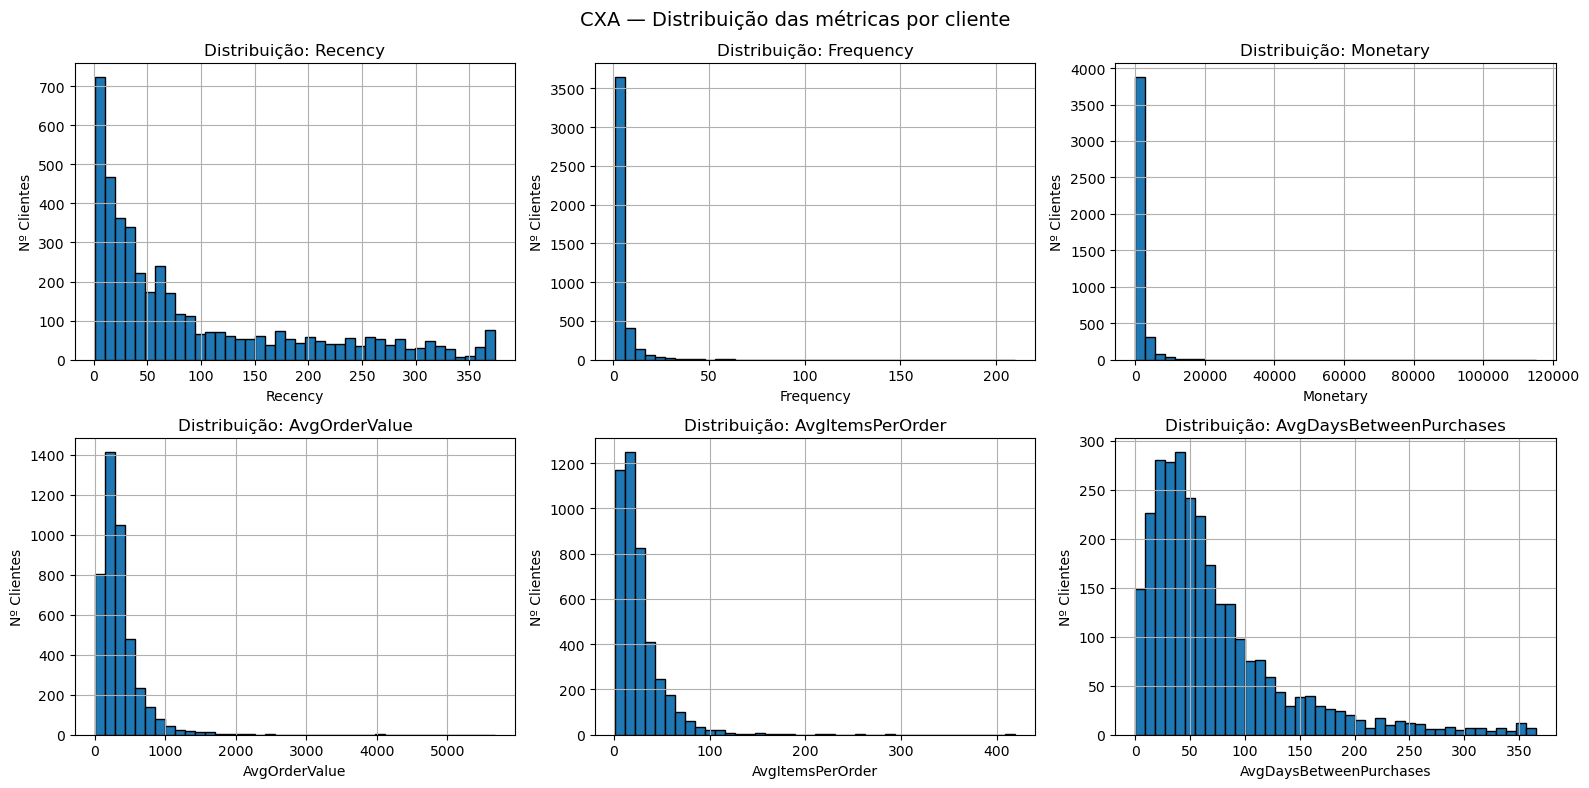

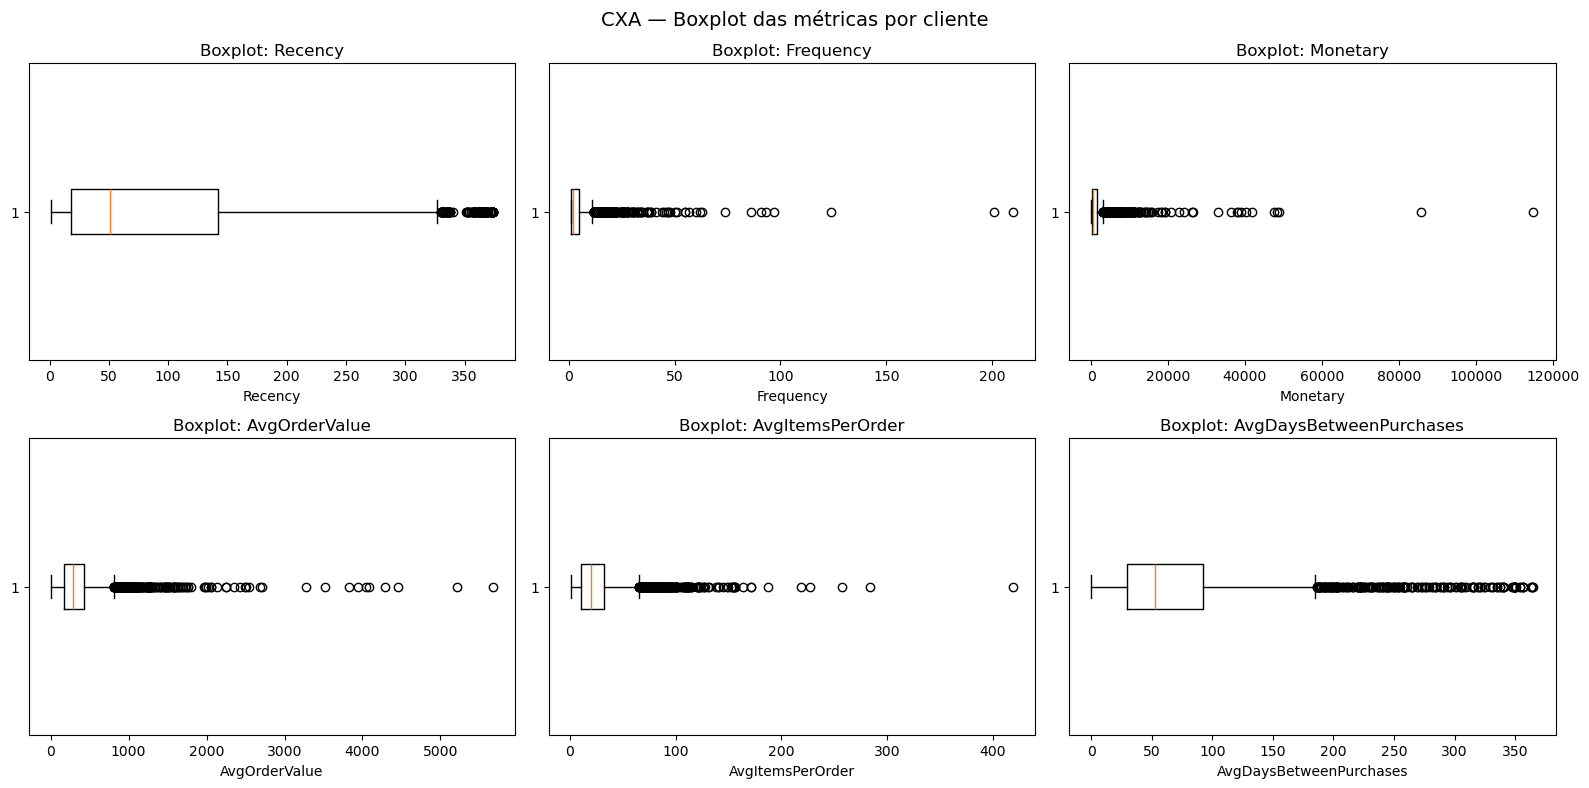

In [257]:
# Visualização da distribuição das principais métricas CXA
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgItemsPerOrder', 'AvgDaysBetweenPurchases']
for ax, col in zip(axes.flat, metrics):
    cxa[col].dropna().hist(bins=40, ax=ax, edgecolor='black')
    ax.set_title(f'Distribuição: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nº Clientes')
plt.suptitle('CXA — Distribuição das métricas por cliente', fontsize=14)
plt.tight_layout()
plt.show()
### skew À direita

## boxplot para identificar outliers nas métricas CXA
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, metrics):
    ax.boxplot(cxa[col].dropna(), vert=False)
    ax.set_title(f'Boxplot: {col}')
    ax.set_xlabel(col)
plt.suptitle('CXA — Boxplot das métricas por cliente', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Tratamento de dados para Clustering

### 4a. Feature Scaling — justificação por atributo

In [258]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Seleção de colunas
cols = [
    'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 
    'AvgItemsPerOrder', 'AvgDaysBetweenPurchases', 'ActiveMonths'
]

cxa_model = cxa[['CustomerID'] + cols].dropna().copy()
X = cxa_model[cols].copy()

# ── Estratégia Log-Standard ──
# 1. Transformação Log (log1p): Corrige a assimetria à direita e reduz a magnitude dos outliers.
# 2. StandardScaler: Garante média 0 e variância 1, essencial para K-Means e PCA.

# Aplicação do Logaritmo
X_log = np.log1p(X)

# Aplicação do Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=cols, index=X.index)

# # Reintegração do CustomerID
# X_final = pd.concat([cxa_model['CustomerID'], X_scaled], axis=1)
X = X_scaled.copy()
# print(X_final[cols].describe().round(3))

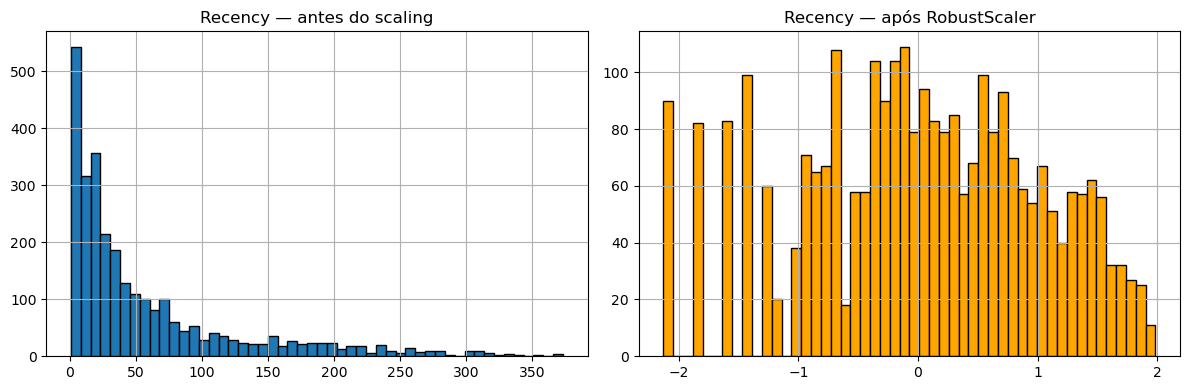

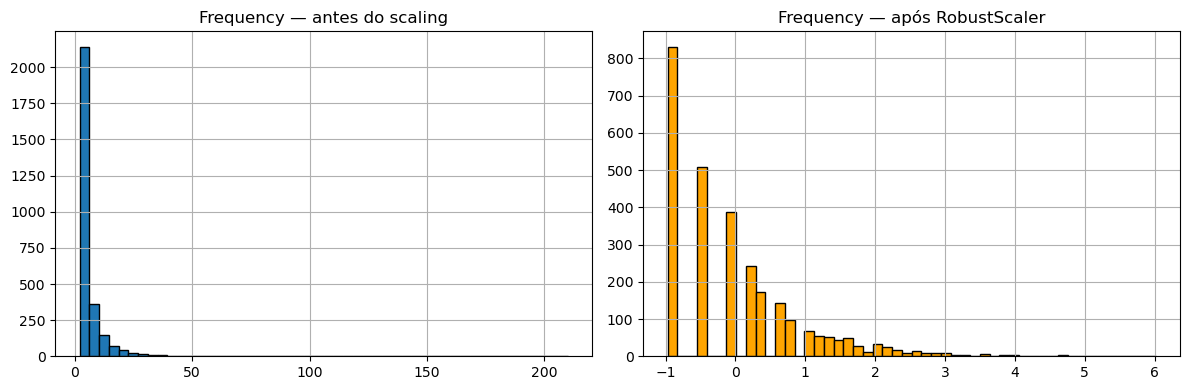

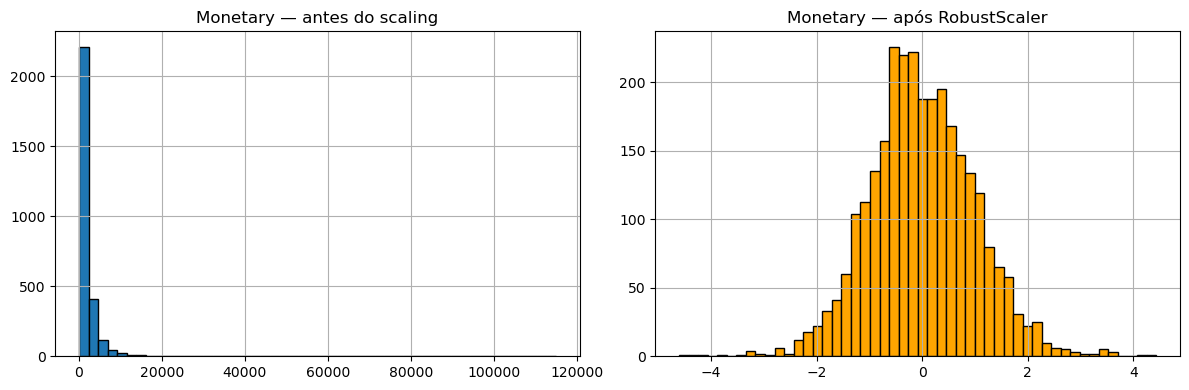

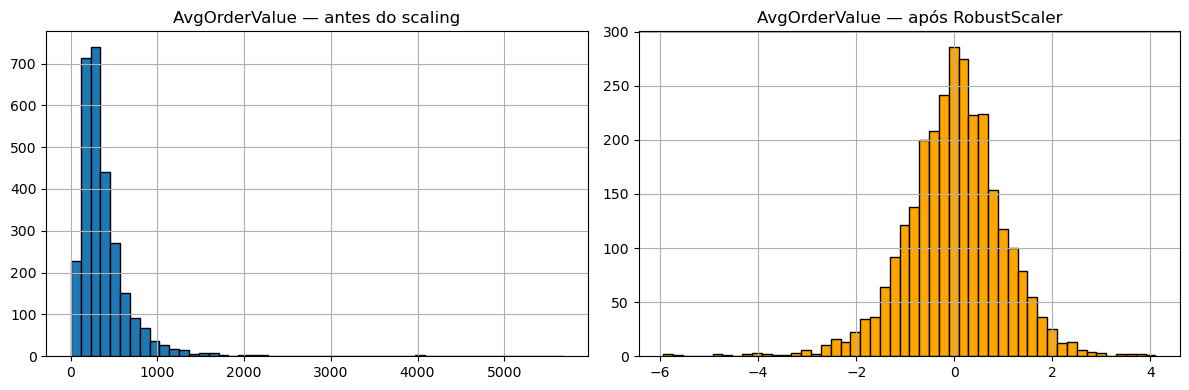

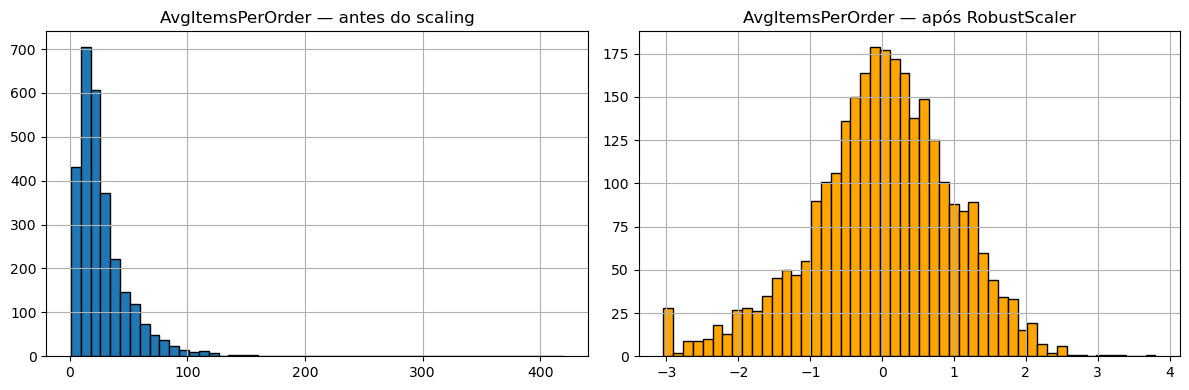

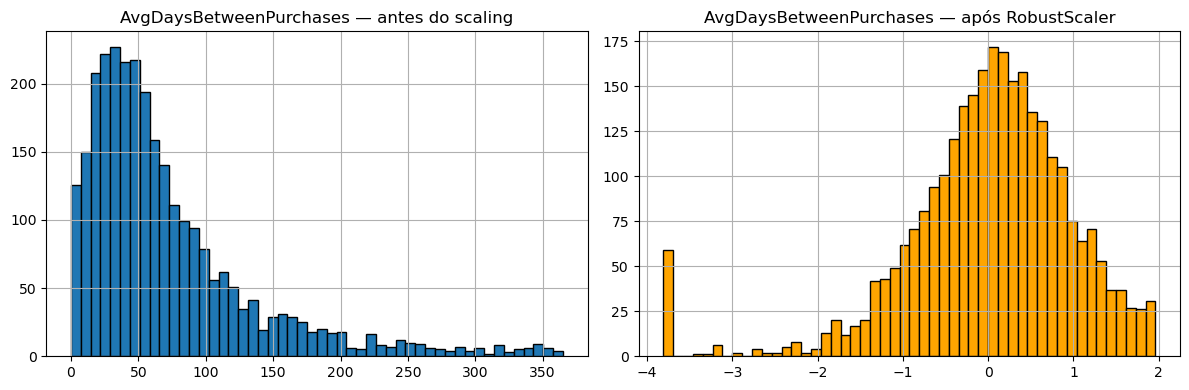

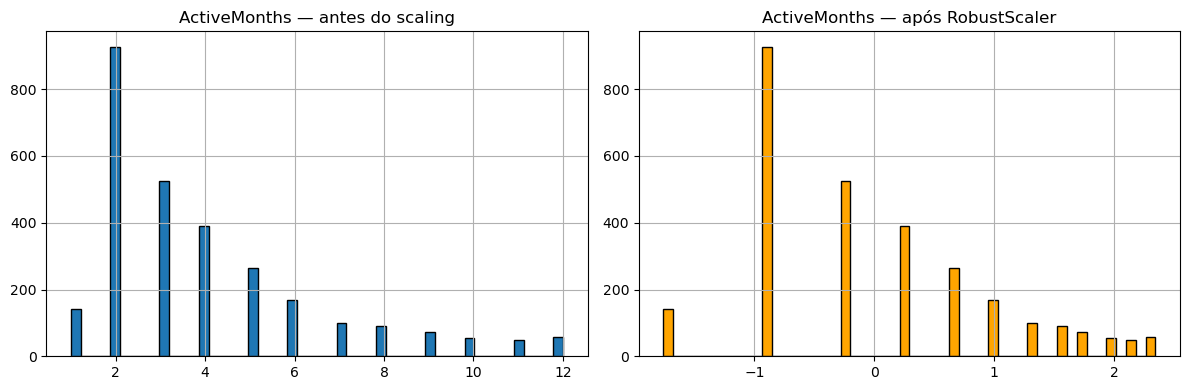

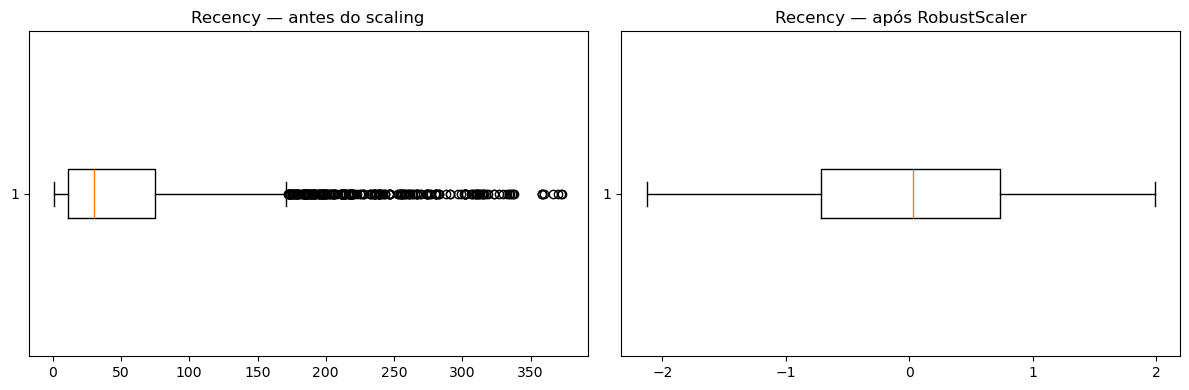

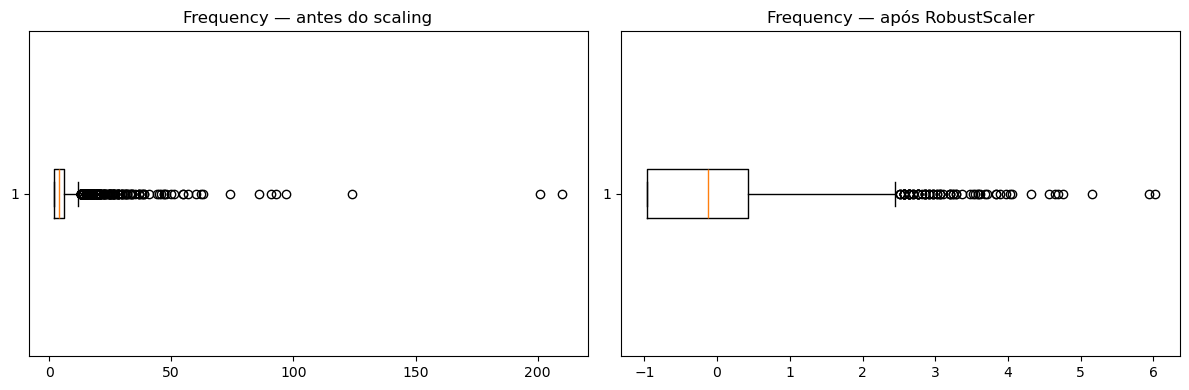

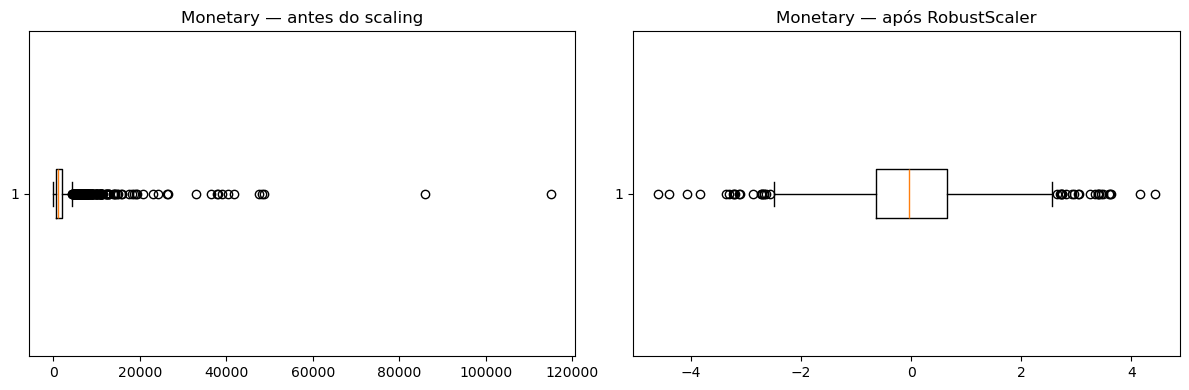

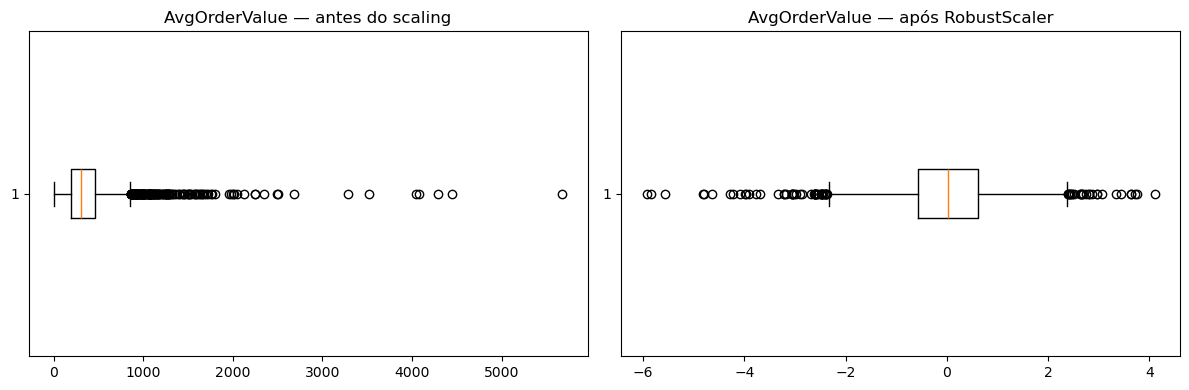

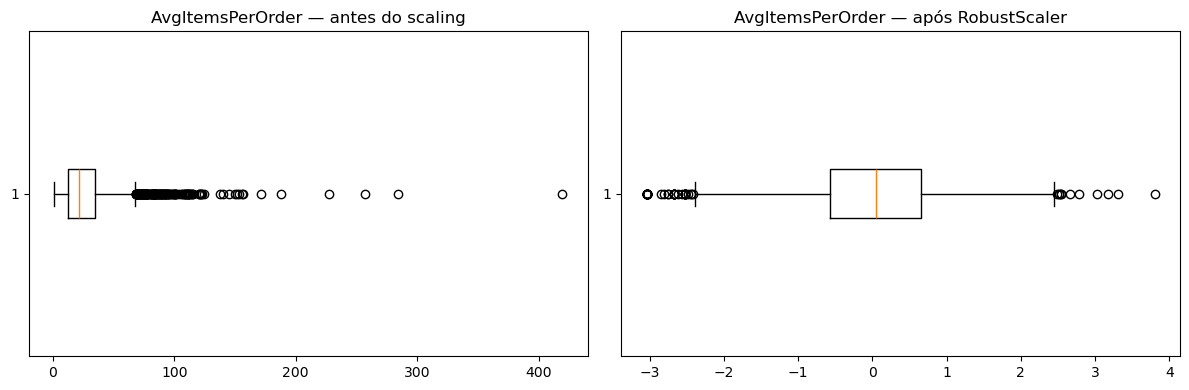

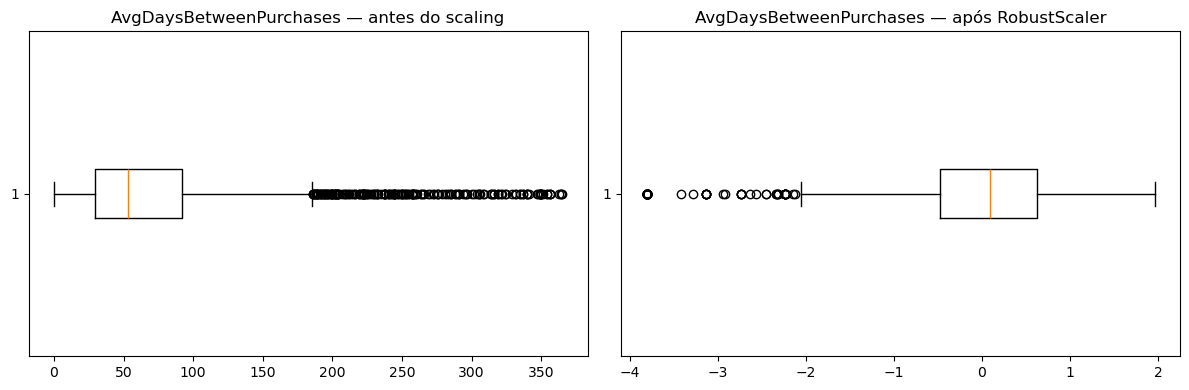

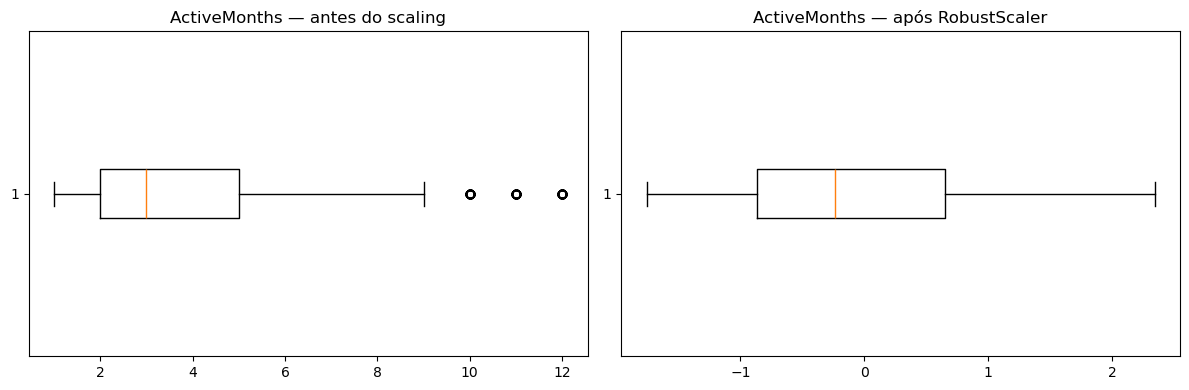

In [ ]:
# Visualização antes vs após scaling
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cxa_model[col].hist(bins=50, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'{col} — antes do scaling')
    X[col].hist(bins=50, ax=axes[1], edgecolor='black', color='orange')
    axes[1].set_title(f'{col} — após StandardScaler')
    plt.tight_layout()
    plt.show()

## boxplot
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].boxplot(cxa_model[col], vert=False)
    axes[0].set_title(f'{col} — antes do scaling')
    axes[1].boxplot(X[col], vert=False)
    axes[1].set_title(f'{col} — após StandardScaler')
    plt.tight_layout()
    plt.show()

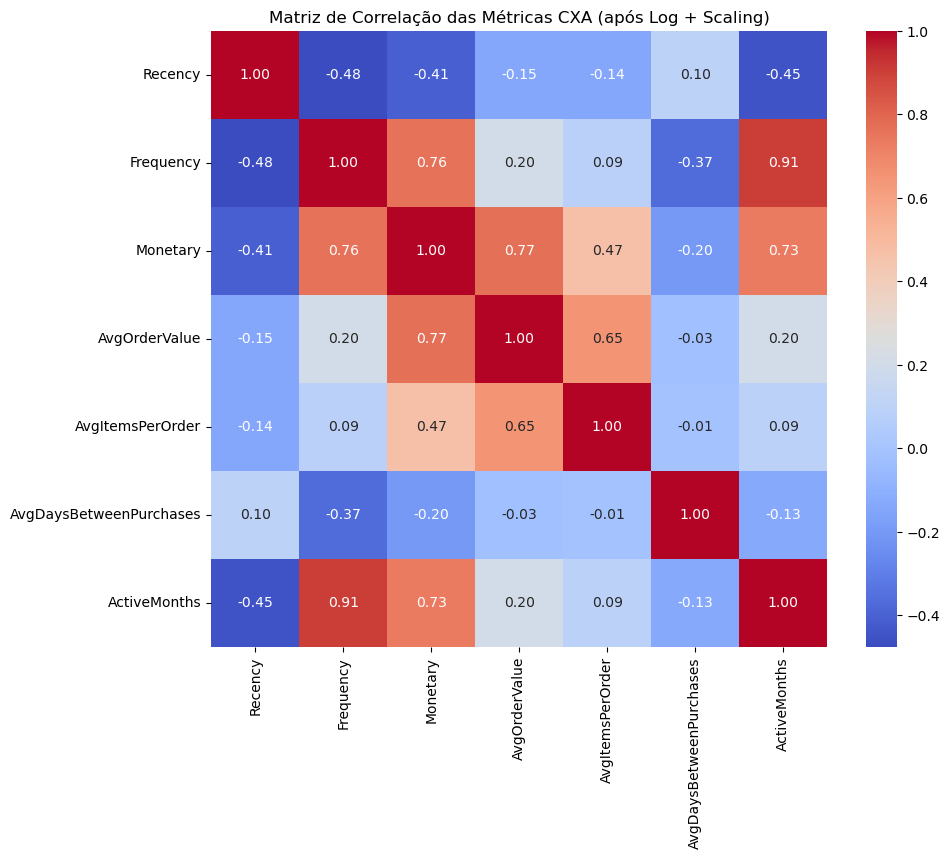

In [260]:
## Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlação das Métricas CXA (após Log + Scaling)')
plt.show()

### 4b. Redimensionamento com PCA

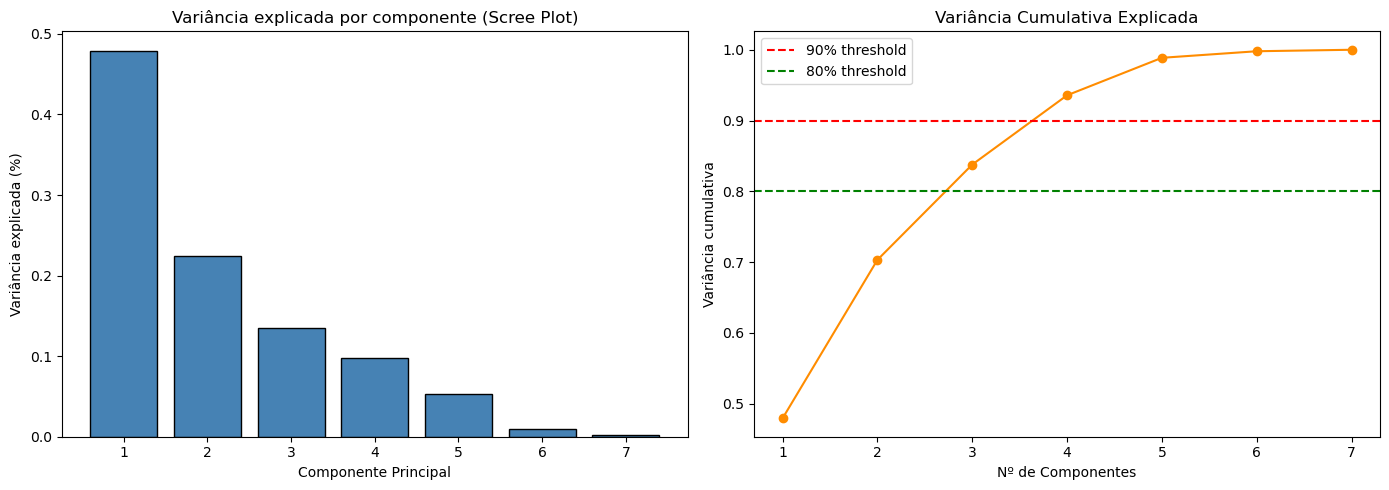

Componentes para 80% variância: 3
Componentes para 90% variância: 4
  PC1: 0.479 (0.479 cumulativo)
  PC2: 0.224 (0.703 cumulativo)
  PC3: 0.135 (0.838 cumulativo)
  PC4: 0.098 (0.936 cumulativo)
  PC5: 0.053 (0.989 cumulativo)
  PC6: 0.009 (0.998 cumulativo)
  PC7: 0.002 (1.000 cumulativo)


In [261]:
from sklearn.decomposition import PCA

# Aplicar PCA sobre os dados escalados
pca_full = PCA()
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot da variância explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância explicada (%)')
axes[0].set_title('Variância explicada por componente (Scree Plot)')

axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='darkorange')
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(0.80, color='green', linestyle='--', label='80% threshold')
axes[1].set_xlabel('Nº de Componentes')
axes[1].set_ylabel('Variância cumulativa')
axes[1].set_title('Variância Cumulativa Explicada')
axes[1].legend()

plt.tight_layout()
plt.show()

n_components_90 = np.argmax(cumulative >= 0.90) + 1
n_components_80 = np.argmax(cumulative >= 0.80) + 1
print(f"Componentes para 80% variância: {n_components_80}")
print(f"Componentes para 90% variância: {n_components_90}")
for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"  PC{i}: {ev:.3f} ({cum:.3f} cumulativo)")

Shape original: (2841, 7)  →  Shape PCA: (2841, 3)

Loadings (contribuição dos atributos em cada PC):


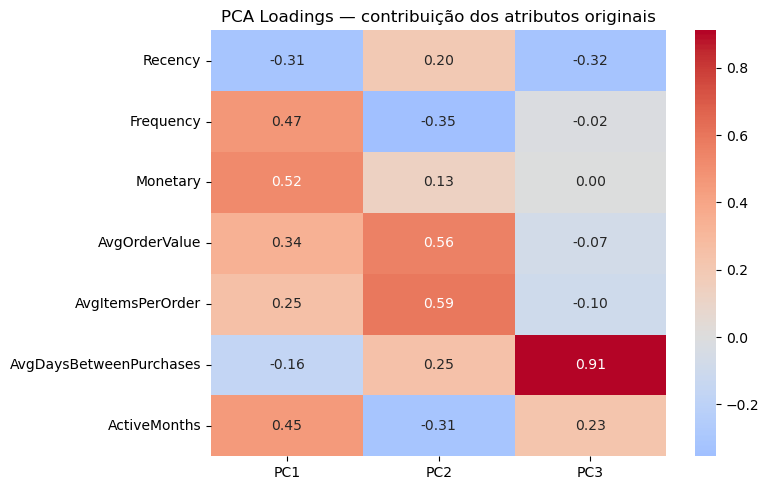

In [ ]:
# ── Decisão: quantos componentes manter ──
# Com base no critério de 80-90% de variância explicada e no Scree Plot (elbow),
# escolhemos n_components = n_components_80 como compromisso entre redução
# dimensional e perda de informação.
# Interpretação dos loadings ajuda a perceber o que cada PC representa.

n_comp = n_components_80
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X)

print(f"Shape original: {X.shape}  →  Shape PCA: {X_pca.shape}")

# Loadings: contribuição de cada atributo por componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)
print("\nLoadings (contribuição dos atributos em cada PC):")
print(loadings.round(3))

# Heatmap dos loadings
plt.figure(figsize=(max(8, n_comp*1.5), 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA Loadings — contribuição dos atributos originais')
plt.tight_layout()
plt.show()

## 5. Análise RFM

In [286]:
# Construção da tabela RFM a partir do CXA já calculado
rfm = cxa[['CustomerID','Recency','Frequency','Monetary']].copy()
rfm = rfm[rfm['CustomerID'] != -1]
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,1381.603852
std,1721.889758,100.009747,7.705493,3506.592236
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,259.600000
50%,15299.000000,51.000000,2.000000,581.880000
75%,16778.500000,142.000000,5.000000,1416.145000
max,18287.000000,374.000000,210.000000,115011.850000


### 5a. 5 clientes mais recentes

In [264]:
# Recency mede dias desde a última compra → menor valor = mais recente
top5_recent = rfm.nsmallest(5, 'Recency')[['CustomerID','Recency']]
print("5 clientes mais recentes (menor Recency = mais recente):")
print(top5_recent.to_string(index=False))

5 clientes mais recentes (menor Recency = mais recente):
 CustomerID  Recency
      12423        1
      12433        1
      12518        1
      12526        1
      12662        1


### 5b. 3 clientes mais recorrentes

In [265]:
top3_frequent = rfm.nlargest(3, 'Frequency')[['CustomerID','Frequency']]
print("3 clientes mais recorrentes (maior nº de faturas distintas):")
print(top3_frequent.to_string(index=False))

3 clientes mais recorrentes (maior nº de faturas distintas):
 CustomerID  Frequency
      12748        210
      14911        201
      17841        124


### 5c. Clientes mais consumidores (maior Monetary)

Top 10 clientes por valor total gasto:
 CustomerID  Monetary
      14911 115011.85
      14646  85888.30
      13089  48777.67
      14156  48300.99
      14096  47494.08
      18102  41866.89
      17511  40291.31
      14088  38934.49
      14298  38181.67
      17841  37945.59


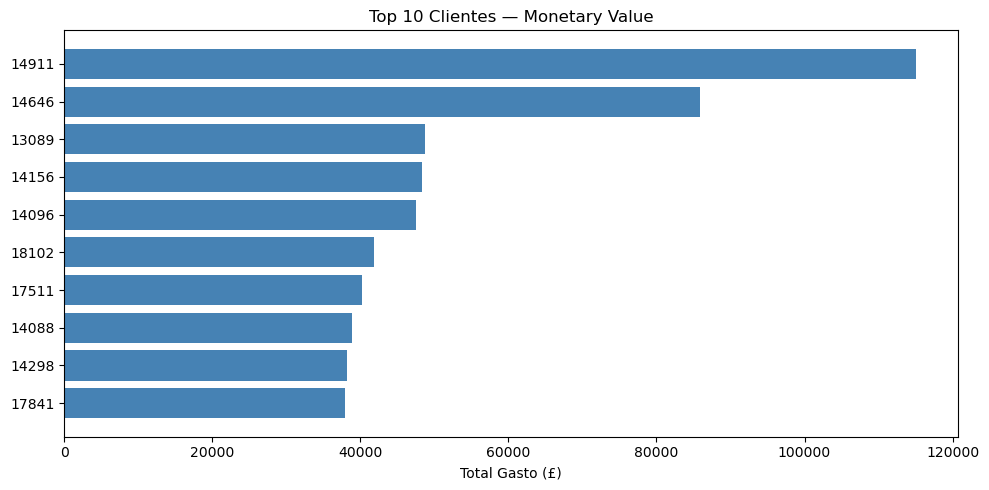

In [266]:
top_monetary = rfm.nlargest(10, 'Monetary')[['CustomerID','Monetary']]
print("Top 10 clientes por valor total gasto:")
print(top_monetary.to_string(index=False))

# Visualização
plt.figure(figsize=(10, 5))
plt.barh(top_monetary['CustomerID'].astype(str), top_monetary['Monetary'], color='steelblue')
plt.xlabel('Total Gasto (£)')
plt.title('Top 10 Clientes — Monetary Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5d. Tempo médio entre compras consecutivas

Tempo médio global entre compras consecutivas: 72.4 dias
Mediana do tempo entre compras: 53.0 dias


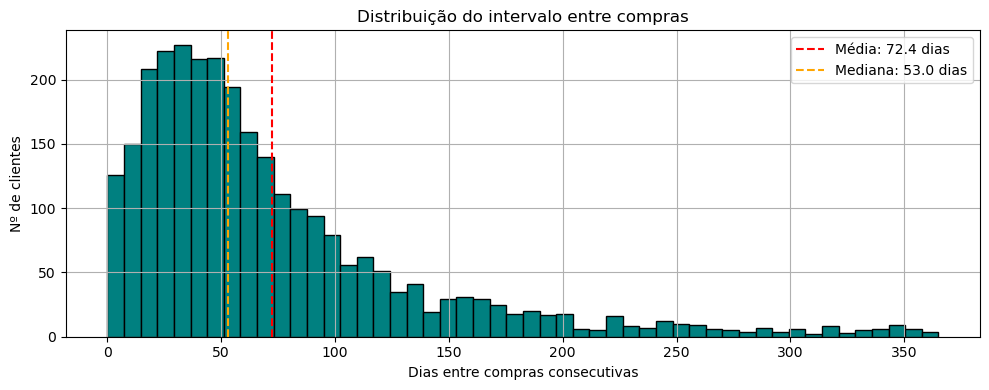

In [267]:
avg_gap = cxa['AvgDaysBetweenPurchases'].mean()
median_gap = cxa['AvgDaysBetweenPurchases'].median()
print(f"Tempo médio global entre compras consecutivas: {avg_gap:.1f} dias")
print(f"Mediana do tempo entre compras: {median_gap:.1f} dias")

plt.figure(figsize=(10, 4))
cxa['AvgDaysBetweenPurchases'].dropna().hist(bins=50, edgecolor='black', color='teal')
plt.axvline(avg_gap, color='red', linestyle='--', label=f'Média: {avg_gap:.1f} dias')
plt.axvline(median_gap, color='orange', linestyle='--', label=f'Mediana: {median_gap:.1f} dias')
plt.xlabel('Dias entre compras consecutivas')
plt.ylabel('Nº de clientes')
plt.title('Distribuição do intervalo entre compras')
plt.legend()
plt.tight_layout()
plt.show()

### 5e. Ganhos gerados por mês

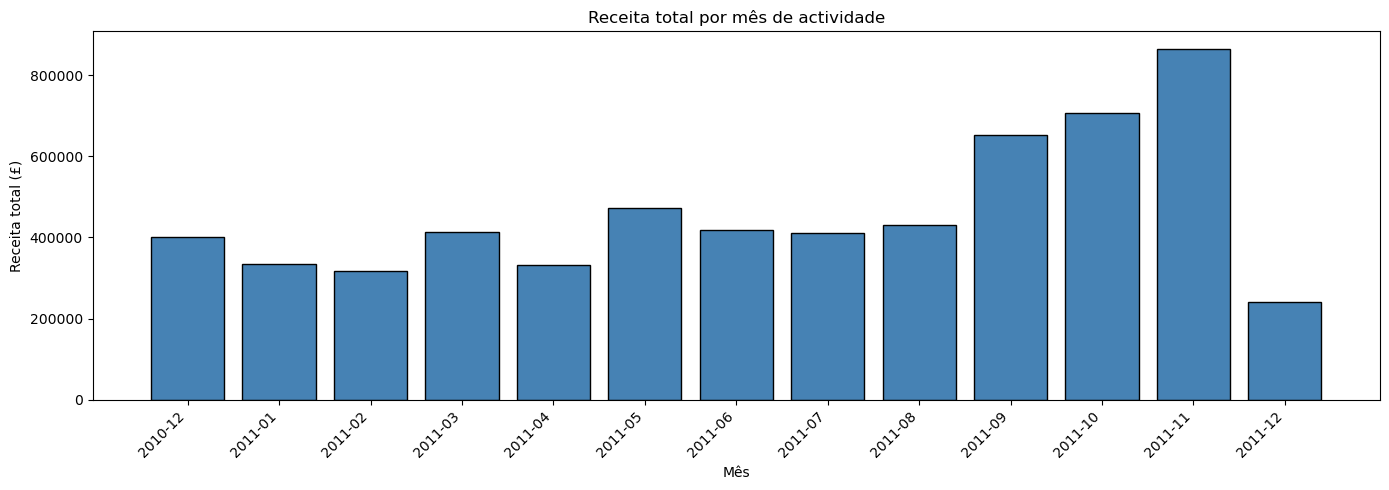

YearMonth  TotalPrice
  2010-12  401560.850
  2011-01  334334.210
  2011-02  316077.530
  2011-03  413764.460
  2011-04  332947.971
  2011-05  473465.960
  2011-06  417205.520
  2011-07  410838.991
  2011-08  430856.080
  2011-09  651754.162
  2011-10  706781.740
  2011-11  864401.660
  2011-12  240789.980


In [268]:
df_valid = df[df['CustomerID'] != -1].copy()
monthly_revenue = (
    df_valid.groupby(['Year', 'Month'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(['Year','Month'])
)
monthly_revenue['YearMonth'] = monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.bar(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'], color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mês')
plt.ylabel('Receita total (£)')
plt.title('Receita total por mês de actividade')
plt.tight_layout()
plt.show()

print(monthly_revenue[['YearMonth','TotalPrice']].to_string(index=False))

### 5f. Média de gastos dos clientes por mês

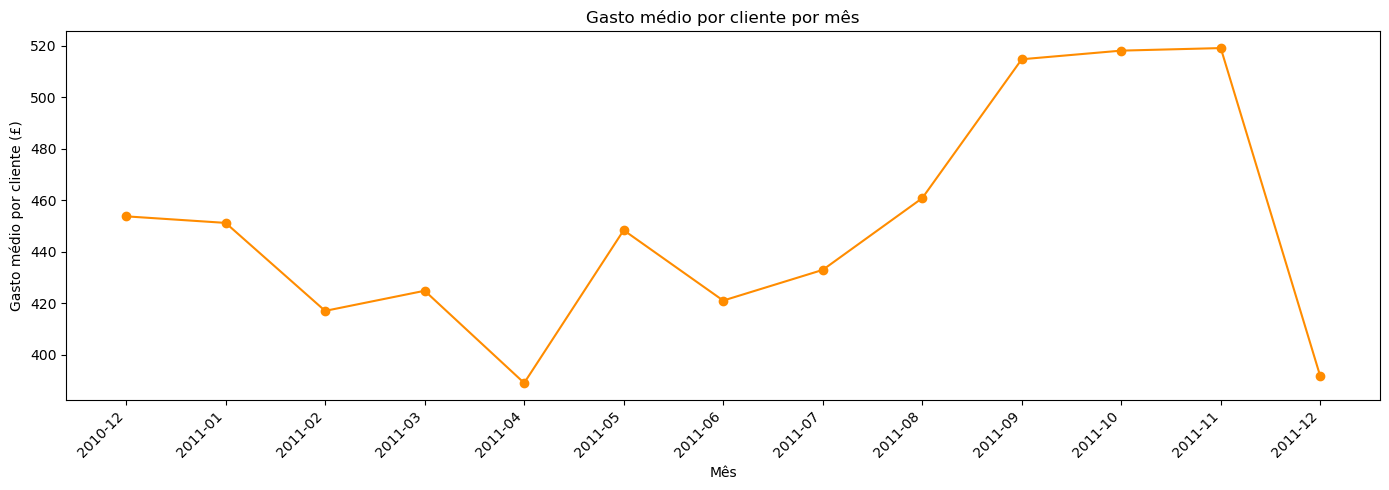

YearMonth  TotalPrice
  2010-12      453.74
  2011-01      451.19
  2011-02      416.99
  2011-03      424.81
  2011-04      388.96
  2011-05      448.36
  2011-06      420.99
  2011-07      432.92
  2011-08      460.81
  2011-09      514.81
  2011-10      518.17
  2011-11      519.16
  2011-12      391.53


In [269]:
# Gasto médio por cliente por mês
monthly_per_cust = (
    df_valid.groupby(['Year', 'Month', 'CustomerID'])['TotalPrice']
    .sum()
    .reset_index()
)
avg_spend_per_month = (
    monthly_per_cust.groupby(['Year', 'Month'])['TotalPrice']
    .mean()
    .reset_index()
    .sort_values(['Year','Month'])
)
avg_spend_per_month['YearMonth'] = (
    avg_spend_per_month['Year'].astype(str) + '-' +
    avg_spend_per_month['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 5))
plt.plot(avg_spend_per_month['YearMonth'], avg_spend_per_month['TotalPrice'],
         marker='o', color='darkorange')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mês')
plt.ylabel('Gasto médio por cliente (£)')
plt.title('Gasto médio por cliente por mês')
plt.tight_layout()
plt.show()

print(avg_spend_per_month[['YearMonth','TotalPrice']].round(2).to_string(index=False))

## 6. Análise do cliente ID 17850

In [292]:
CUST_ID = 12748
df_c = df[df['CustomerID'] == CUST_ID].copy()
print(f"Nº de registos do cliente {CUST_ID}: {len(df_c)}")
print(f"Período activo: {df_c['InvoiceDate'].min()} → {df_c['InvoiceDate'].max()}")

Nº de registos do cliente 12748: 4413
Período activo: 2010-12-01 12:48:00 → 2011-12-09 12:20:00


### 6a. Transação mais recente

In [293]:
most_recent_row = df_c.loc[df_c['InvoiceDate'].idxmax()]
print(f"Transação mais recente do cliente {CUST_ID}:")
print(most_recent_row[['InvoiceNo','InvoiceDate','Description','Quantity','UnitPrice','TotalPrice']].to_string())

Transação mais recente do cliente 12748:
InvoiceNo                        581580
InvoiceDate         2011-12-09 12:20:00
Description    IVORY WICKER HEART SMALL
Quantity                              4
UnitPrice                          0.63
TotalPrice                         2.52


### 6b. Transações por mês

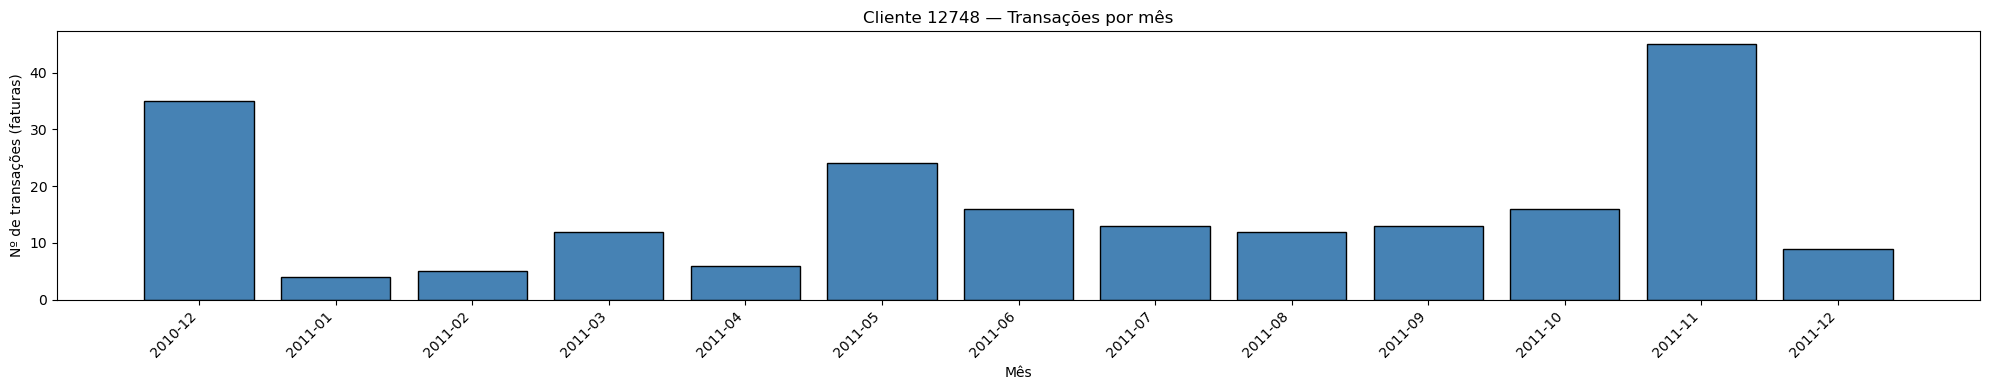

YearMonth  Transações
  2010-12          35
  2011-01           4
  2011-02           5
  2011-03          12
  2011-04           6
  2011-05          24
  2011-06          16
  2011-07          13
  2011-08          12
  2011-09          13
  2011-10          16
  2011-11          45
  2011-12           9


In [294]:
# Conta faturas distintas por mês ao longo dos anos para o cliente específico

monthly_tx = (
    df_c.groupby(['Year','Month'])['InvoiceNo']
    .nunique()
    .reset_index()
    .sort_values(['Year','Month'])
)
monthly_tx['YearMonth'] = monthly_tx['Year'].astype(str) + '-' + monthly_tx['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(20, 4))
plt.bar(monthly_tx['YearMonth'], monthly_tx['InvoiceNo'], color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mês')
plt.ylabel('Nº de transações (faturas)')
plt.title(f'Cliente {CUST_ID} — Transações por mês')
plt.tight_layout()
plt.show()

print(monthly_tx[['YearMonth','InvoiceNo']].rename(columns={'InvoiceNo':'Transações'}).to_string(index=False))

### 6c. Lucro por mês, lucro total e média de gastos por transação

Lucro total gerado pelo cliente 12748: £26578.67
Nº de transações distintas: 210
Média de gastos por transação: £126.57


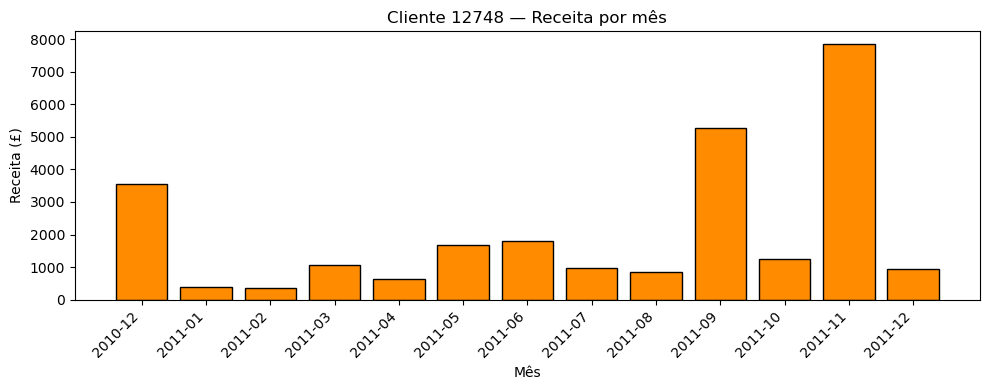

YearMonth  TotalPrice
  2010-12     3561.62
  2011-01      375.92
  2011-02      366.29
  2011-03     1053.61
  2011-04      632.97
  2011-05     1682.07
  2011-06     1795.74
  2011-07      961.00
  2011-08      846.79
  2011-09     5266.42
  2011-10     1245.80
  2011-11     7844.84
  2011-12      945.60


In [295]:
monthly_profit = (
    df_c.groupby(['Year','Month'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(['Year','Month'])
)
monthly_profit['YearMonth'] = monthly_profit['Year'].astype(str) + '-' + monthly_profit['Month'].astype(str).str.zfill(2)

total_profit = df_c['TotalPrice'].sum()
n_invoices = df_c['InvoiceNo'].nunique()
avg_per_tx = total_profit / n_invoices

print(f"Lucro total gerado pelo cliente {CUST_ID}: £{total_profit:.2f}")
print(f"Nº de transações distintas: {n_invoices}")
print(f"Média de gastos por transação: £{avg_per_tx:.2f}")

plt.figure(figsize=(10, 4))
plt.bar(monthly_profit['YearMonth'], monthly_profit['TotalPrice'], color='darkorange', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mês')
plt.ylabel('Receita (£)')
plt.title(f'Cliente {CUST_ID} — Receita por mês')
plt.tight_layout()
plt.show()

print(monthly_profit[['YearMonth','TotalPrice']].round(2).to_string(index=False))

### 6d. Períodos de maior actividade e categoria mais comprada nesses períodos

Hora de maior actividade: 12h (35 faturas)
Dia de maior actividade: Sexta (59 faturas)


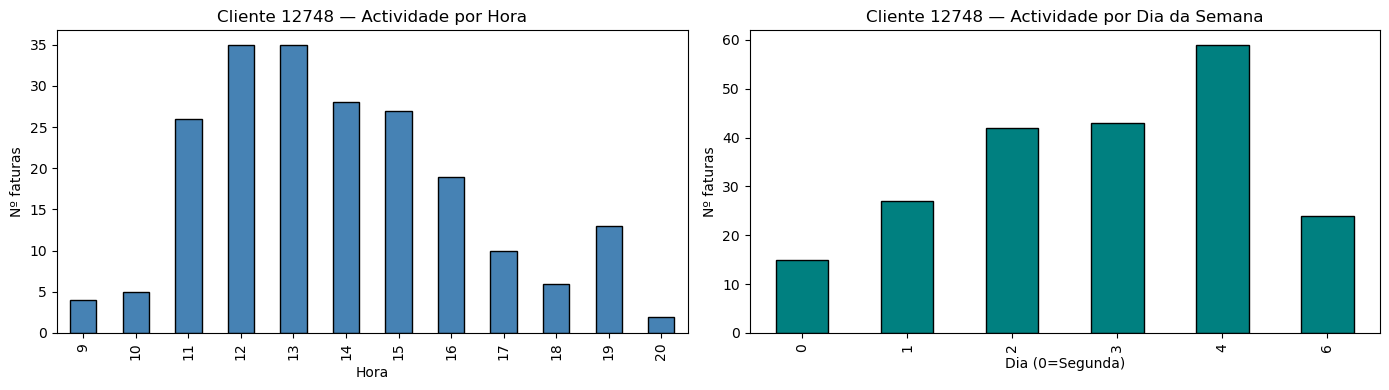

In [296]:
# ── Actividade por hora do dia ──
hourly = df_c.groupby('Hour')['InvoiceNo'].nunique()
peak_hour = hourly.idxmax()

# ── Actividade por dia da semana ──
day_names = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
weekly = df_c.groupby('DayOfWeek')['InvoiceNo'].nunique()
peak_day = weekly.idxmax()

print(f"Hora de maior actividade: {peak_hour}h ({hourly[peak_hour]} faturas)")
print(f"Dia de maior actividade: {day_names[peak_day]} ({weekly[peak_day]} faturas)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title(f'Cliente {CUST_ID} — Actividade por Hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Nº faturas')

weekly.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title(f'Cliente {CUST_ID} — Actividade por Dia da Semana')
axes[1].set_xlabel('Dia (0=Segunda)')
axes[1].set_ylabel('Nº faturas')
plt.tight_layout()
plt.show()

# ── Categoria mais comprada nas horas de pico ──
df_peak_hour = df_c[df_c['Hour'] == peak_hour]

df_peak_day = df_c[df_c['DayOfWeek'] == peak_day]

## 7. Clustering — K-Means e DBSCAN

### 7a. Clustering por categoria de produto (preço médio por unidade)

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# ── Custo médio por unidade de cada categoria ──
cat_price = (
    df[df['UnitPrice'] > 0]
    .groupby('Category')
    .agg(
        AvgUnitPrice = ('UnitPrice', 'mean'),
        MedianUnitPrice = ('UnitPrice', 'median'),
        TotalRevenue = ('TotalPrice', 'sum'),
        TotalQty = ('Quantity', 'sum')
    )
    .reset_index()
)

# ── Atribuição de rótulo manual com base em tercis ──
q33 = cat_price['AvgUnitPrice'].quantile(0.33)
q66 = cat_price['AvgUnitPrice'].quantile(0.66)

def price_label(p):
    if p <= q33:
        return 'Baixo'
    elif p <= q66:
        return 'Médio'
    else:
        return 'Alto'

cat_price['PriceLabel'] = cat_price['AvgUnitPrice'].apply(price_label)
print(cat_price[['Category','AvgUnitPrice','PriceLabel']].sort_values('AvgUnitPrice').to_string(index=False))

    Category  AvgUnitPrice PriceLabel
        PADS      0.001000      Baixo
       16045      0.043478      Baixo
       16259      0.096774      Baixo
      16161G      0.100000      Baixo
      17136A      0.102941      Baixo
       16033      0.120000      Baixo
       16043      0.120000      Baixo
       16010      0.120000      Baixo
       16054      0.129091      Baixo
       16008      0.136143      Baixo
      47518F      0.141429      Baixo
       16216      0.152444      Baixo
       20668      0.164450      Baixo
      79063C      0.189286      Baixo
      35607B      0.190000      Baixo
       47420      0.190000      Baixo
      84201B      0.190000      Baixo
      46115B      0.190000      Baixo
      84206B      0.190000      Baixo
      84206C      0.190000      Baixo
      35271S      0.190000      Baixo
      81953B      0.190000      Baixo
      81952V      0.190000      Baixo
      81952B      0.190000      Baixo
      84201C      0.190000      Baixo
       72232

Comparação: rótulo manual vs cluster K-Means
    Category  AvgUnitPrice PriceLabel  KMeans_Cluster
        PADS      0.001000      Baixo               0
       16045      0.043478      Baixo               0
       16259      0.096774      Baixo               0
      16161G      0.100000      Baixo               0
      17136A      0.102941      Baixo               0
       16033      0.120000      Baixo               0
       16043      0.120000      Baixo               0
       16010      0.120000      Baixo               0
       16054      0.129091      Baixo               0
       16008      0.136143      Baixo               0
      47518F      0.141429      Baixo               0
       16216      0.152444      Baixo               0
       20668      0.164450      Baixo               0
      79063C      0.189286      Baixo               0
      35607B      0.190000      Baixo               0
       47420      0.190000      Baixo               0
      84201B      0.190000      Baixo

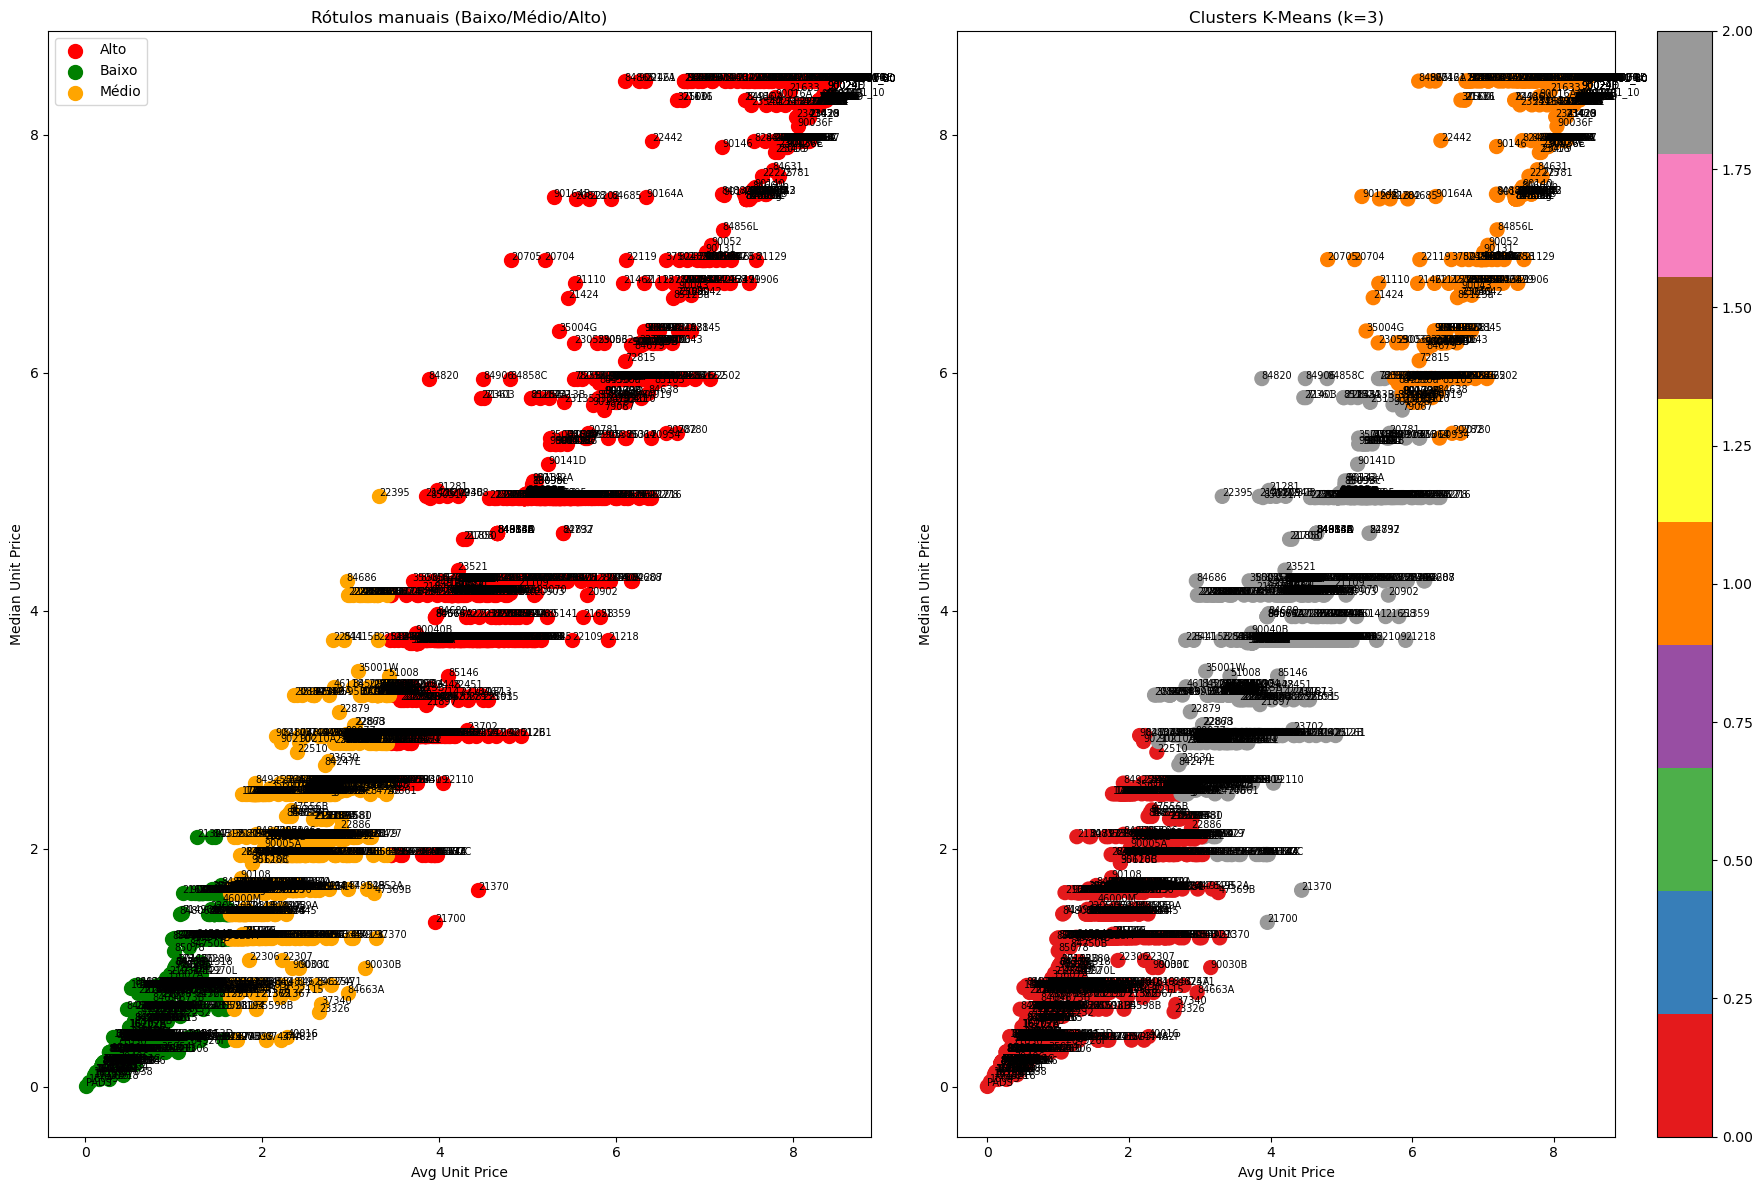

In [299]:
# ── K-Means sobre categorias ──
# Features: AvgUnitPrice, MedianUnitPrice, TotalRevenue (normalizado)
X_cat = cat_price[['AvgUnitPrice','MedianUnitPrice']].values
scaler_cat = StandardScaler()
X_cat_scaled = scaler_cat.fit_transform(X_cat)

# Testamos k=3 para validar a divisão Baixo/Médio/Alto
kmeans_cat = KMeans(n_clusters=3, random_state=42, n_init=10)
cat_price['KMeans_Cluster'] = kmeans_cat.fit_predict(X_cat_scaled)

# Comparação rótulo manual vs cluster K-Means
print("Comparação: rótulo manual vs cluster K-Means")
print(cat_price[['Category','AvgUnitPrice','PriceLabel','KMeans_Cluster']]
      .sort_values('AvgUnitPrice').to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
colors_manual = {'Baixo':'green','Médio':'orange','Alto':'red'}
for label, group in cat_price.groupby('PriceLabel'):
    axes[0].scatter(group['AvgUnitPrice'], group['MedianUnitPrice'],
                    label=label, color=colors_manual[label], s=100)
    for _, row in group.iterrows():
        axes[0].annotate(row['Category'], (row['AvgUnitPrice'], row['MedianUnitPrice']), fontsize=7)
axes[0].set_title('Rótulos manuais (Baixo/Médio/Alto)')
axes[0].legend()
axes[0].set_xlabel('Avg Unit Price')
axes[0].set_ylabel('Median Unit Price')

scatter = axes[1].scatter(cat_price['AvgUnitPrice'], cat_price['MedianUnitPrice'],
                           c=cat_price['KMeans_Cluster'], cmap='Set1', s=100)
for _, row in cat_price.iterrows():
    axes[1].annotate(row['Category'], (row['AvgUnitPrice'], row['MedianUnitPrice']), fontsize=7)
axes[1].set_title('Clusters K-Means (k=3)')
axes[1].set_xlabel('Avg Unit Price')
axes[1].set_ylabel('Median Unit Price')
plt.colorbar(scatter, ax=axes[1])
plt.tight_layout()
plt.show()

In [301]:
# ── DBSCAN sobre categorias ──
# DBSCAN não requer k fixo; identifica outliers como ruído.
# Para dados tão reduzidos (9 categorias), DBSCAN funciona mais como validação de outliers.
dbscan_cat = DBSCAN(eps=0.8, min_samples=2)
cat_price['DBSCAN_Cluster'] = dbscan_cat.fit_predict(X_cat_scaled)

print("DBSCAN sobre categorias (−1 = ruído/outlier):")
print(cat_price[['Category','AvgUnitPrice','PriceLabel','KMeans_Cluster','DBSCAN_Cluster']]
      .sort_values('AvgUnitPrice').to_string(index=False))

DBSCAN sobre categorias (−1 = ruído/outlier):
    Category  AvgUnitPrice PriceLabel  KMeans_Cluster  DBSCAN_Cluster
        PADS      0.001000      Baixo               0               0
       16045      0.043478      Baixo               0               0
       16259      0.096774      Baixo               0               0
      16161G      0.100000      Baixo               0               0
      17136A      0.102941      Baixo               0               0
       16033      0.120000      Baixo               0               0
       16043      0.120000      Baixo               0               0
       16010      0.120000      Baixo               0               0
       16054      0.129091      Baixo               0               0
       16008      0.136143      Baixo               0               0
      47518F      0.141429      Baixo               0               0
       16216      0.152444      Baixo               0               0
       20668      0.164450      Baixo       

### 7b. Segmentação de clientes com K-Means e DBSCAN (RFM)

In [278]:
# ── Preparação dos dados RFM para clustering ──
rfm_clean = rfm[rfm['CustomerID'] != -1].dropna().copy()

# Log-transform nas variáveis altamente assimétricas antes do StandardScaler
rfm_clean['log_Recency']   = np.log1p(rfm_clean['Recency'])
rfm_clean['log_Frequency'] = np.log1p(rfm_clean['Frequency'])
rfm_clean['log_Monetary']  = np.log1p(rfm_clean['Monetary'])

X_rfm = rfm_clean[['log_Recency','log_Frequency','log_Monetary']].values
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

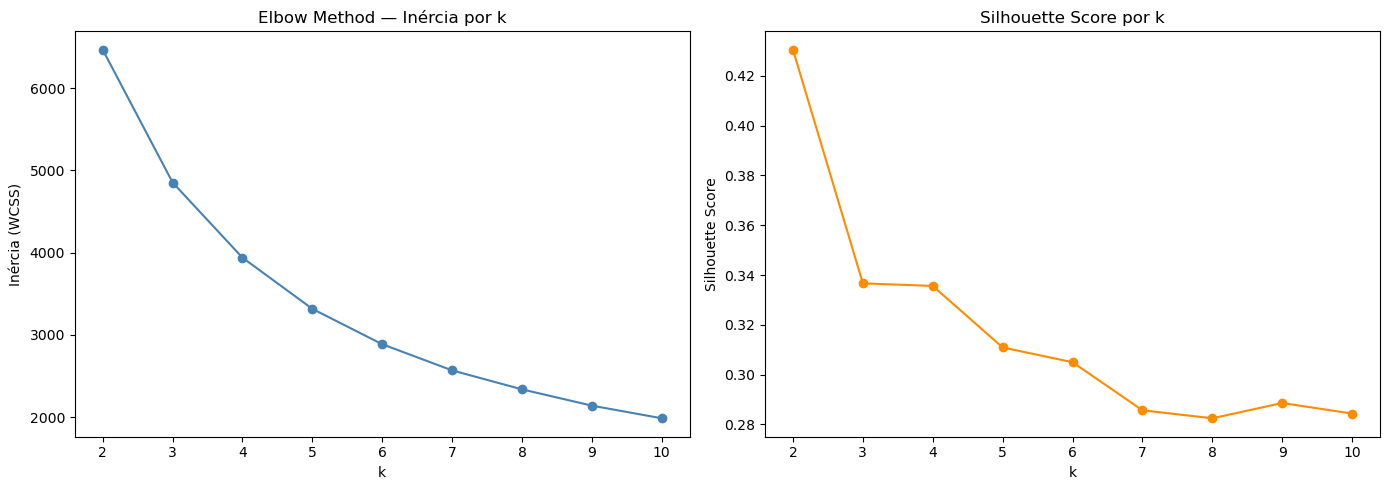

k sugerido pelo Silhouette Score: 2  (score=0.431)


In [302]:
# ── Método do Cotovelo (Elbow Method) para escolher k ──
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Elbow Method — Inércia por k')

axes[1].plot(K_range, sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"k sugerido pelo Silhouette Score: {best_k}  (score={max(sil_scores):.3f})")

In [280]:
# ── K-Means final com k óptimo ──
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm_clean['KMeans_Segment'] = km_final.fit_predict(X_rfm_scaled)

# Perfil médio por segmento
profile_km = rfm_clean.groupby('KMeans_Segment')[['Recency','Frequency','Monetary']].mean().round(1)
print("Perfil médio dos segmentos K-Means:")
print(profile_km)

# ── Interpretação dos segmentos ──
# Atribuímos rótulos semânticos com base no perfil:
#   • Alta Frequência + Alto Monetary + Baixa Recency → "Champions"
#   • Alta Recency (inactivos) + Baixo Monetary → "At Risk / Lost"
#   • Médios em tudo → "Potential Loyalists"
# (os rótulos exatos dependem dos centróides obtidos em runtime)

Perfil médio dos segmentos K-Means:
                Recency  Frequency  Monetary
KMeans_Segment                              
0                 135.4        1.7     405.9
1                  26.1        8.3    2891.9


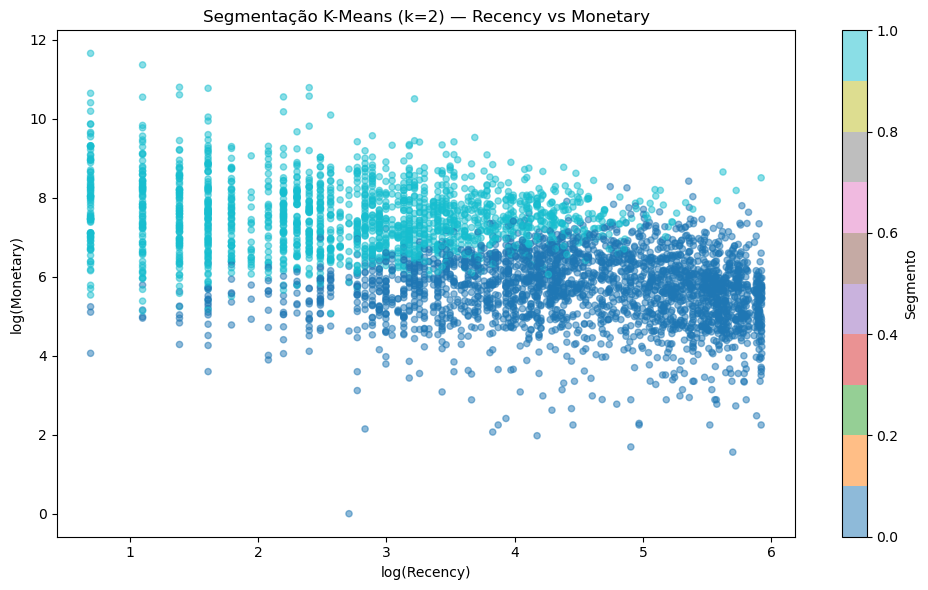

In [281]:
# Scatter plot RFM 2D (Recency vs Monetary) colorido por segmento K-Means
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm_clean['log_Recency'], rfm_clean['log_Monetary'],
    c=rfm_clean['KMeans_Segment'], cmap='tab10', alpha=0.5, s=20
)
plt.xlabel('log(Recency)')
plt.ylabel('log(Monetary)')
plt.title(f'Segmentação K-Means (k={best_k}) — Recency vs Monetary')
plt.colorbar(scatter, label='Segmento')
plt.tight_layout()
plt.show()

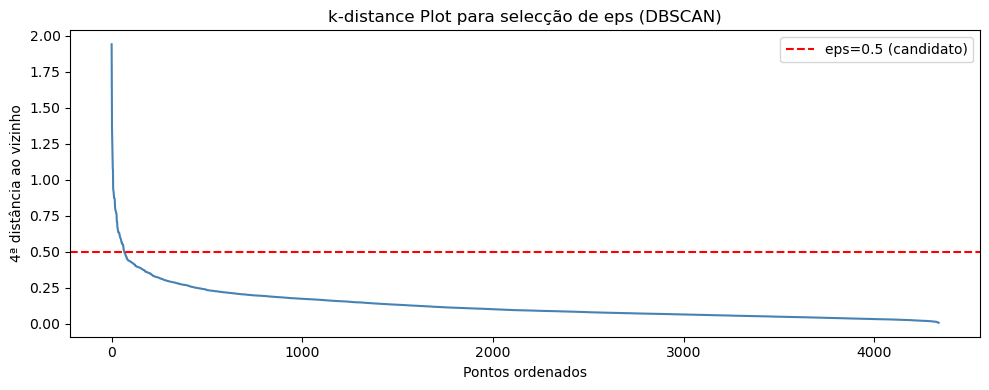

In [282]:
# ── DBSCAN para segmentação de clientes ──
# DBSCAN não requer k pré-definido e é robusto a formas não esféricas.
# Desvantagem: sensível a eps e min_samples; clientes "raros" ficam como ruído (−1).

# Pesquisa de eps com k-distance plot (distância ao 4º vizinho mais próximo)
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=4).fit(X_rfm_scaled)
distances, _ = nbrs.kneighbors(X_rfm_scaled)
k_dist = np.sort(distances[:, 3])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_dist, color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps=0.5 (candidato)')
plt.xlabel('Pontos ordenados')
plt.ylabel('4ª distância ao vizinho')
plt.title('k-distance Plot para selecção de eps (DBSCAN)')
plt.legend()
plt.tight_layout()
plt.show()

DBSCAN: 3 clusters encontrados, 49 pontos de ruído (1.1%)
                Recency  Frequency  Monetary
DBSCAN_Segment                              
-1                 58.3       34.0   15288.7
 0                156.9        1.0     291.2
 1                 59.0        5.4    1675.9
 2                  6.8       47.0   25252.8


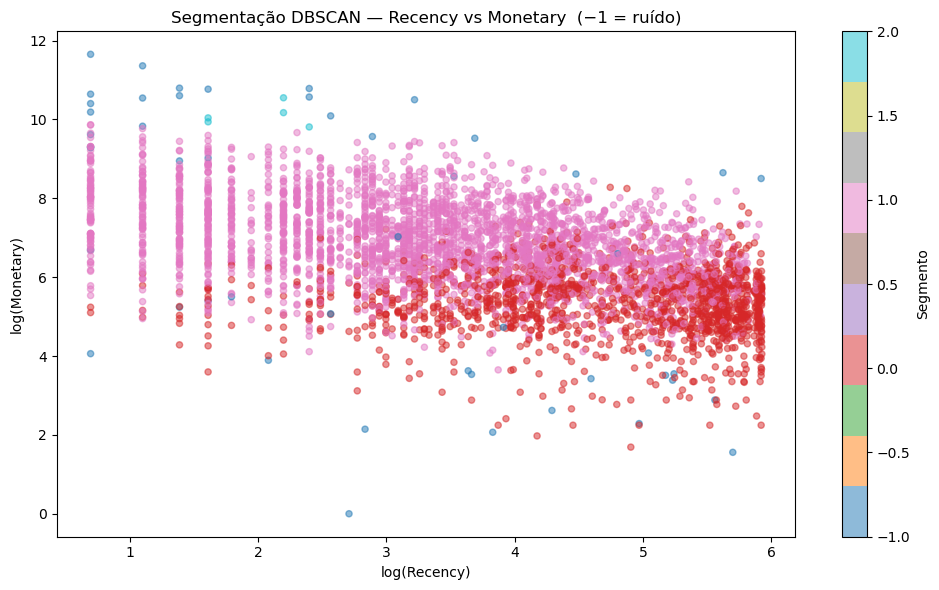

In [283]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm_clean['DBSCAN_Segment'] = dbscan.fit_predict(X_rfm_scaled)

n_clusters_db = len(set(rfm_clean['DBSCAN_Segment'])) - (1 if -1 in rfm_clean['DBSCAN_Segment'].values else 0)
n_noise = (rfm_clean['DBSCAN_Segment'] == -1).sum()
print(f"DBSCAN: {n_clusters_db} clusters encontrados, {n_noise} pontos de ruído ({n_noise/len(rfm_clean)*100:.1f}%)")
print(rfm_clean.groupby('DBSCAN_Segment')[['Recency','Frequency','Monetary']].mean().round(1))

# Visualização DBSCAN
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm_clean['log_Recency'], rfm_clean['log_Monetary'],
    c=rfm_clean['DBSCAN_Segment'], cmap='tab10', alpha=0.5, s=20
)
plt.xlabel('log(Recency)')
plt.ylabel('log(Monetary)')
plt.title(f'Segmentação DBSCAN — Recency vs Monetary  (−1 = ruído)')
plt.colorbar(scatter, label='Segmento')
plt.tight_layout()
plt.show()

In [ ]:
# ── Comparação K-Means vs DBSCAN ──
# Distribuição de clientes por segmento
print("K-Means — distribuição por segmento:")
print(rfm_clean['KMeans_Segment'].value_counts().sort_index())
print("\nDBSCAN — distribuição por segmento (−1=ruído):")
print(rfm_clean['DBSCAN_Segment'].value_counts().sort_index())

K-Means — distribuição por segmento:
KMeans_Segment
0    2636
1    1703
Name: count, dtype: int64

DBSCAN — distribuição por segmento (−1=ruído):
DBSCAN_Segment
-1      49
 0    1489
 1    2796
 2       5
Name: count, dtype: int64
